# Taller 4: Optimización de despliegue PON

Integrantes:
* Camila Herrera
* Gustavo Venegas
* Javier Cáceres

## Secciones del Jupyter

1. Preparar herramientas (instalaciones e imports + Numba).
2. Seleccionar áreas de estudio (Urbana, Semi-Urbana, Rural).
3. Extraer topología de OpenStreetMap (OSMnx) para cada área.
4. Generar usuarios y calcular posiciones de splitters basado en clustering.
5. Calcular rutas con distancia Manhattan desde splitters a usuarios.
6. Calcular Power Budget para validación de transmisión.
7. **Bucle iterativo**: Formular y resolver ILP con restricciones de Power Budget.
8. Si hay usuarios sin cobertura, reposicionar splitters y volver a paso 7.
9. Validar presupuesto óptico y latencia del diseño final.
10. Visualización del resultado (mapas estático e interactivo).

## 1. Preparación: instalación e imports

Se preparan las herramientas y librerías necesarias, definiendo parámetros globales del modelo:

**Parámetros económicos:**
- Costo de fibra por metro y costo de splitters

**Parámetros del Power Budget (GPON):**
- **Potencia transmitida (OLT)**: Típicamente +2 a +7 dBm (clase B+)
- **Sensibilidad del receptor (ONU)**: -28 dBm (clase B+)
- **Margen de sistema**: 3 dB (reserva para degradación y mantenimiento)
- **Atenuación de fibra**: 0.35 dB/km
- **Pérdidas por conectores y empalmes**
- **Pérdida por splitter**: según ratio (tabla ITU-T)

El **Power Budget** máximo disponible determina el alcance y topología factible.

In [1]:
# Imports necesarios
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp
import folium
from folium import plugins
from shapely.geometry import Point, Polygon
import heapq
from sklearn.cluster import KMeans, DBSCAN
import numba
from numba import jit, prange
import warnings
warnings.filterwarnings('ignore')

# Parámetros del modelo económico
COST_FIBER_PER_M = 1.0    # Costo unitario por metro de fibra
COST_SPLITTER = 200.0      # Costo de instalación de splitter
SPLIT_RATIO = 32           # Capacidad máxima: usuarios por splitter (1:32)

# Parámetros del Power Budget GPON REALES (según especificaciones del fabricante)
# ONT Downlink: 1490nm, Sensibilidad -28dBm, Saturación -8dBm
# ONT Uplink: 1310nm, TX power 0.5~5dBm
TX_POWER_DBM = 5.0         # Potencia transmitida por OLT (dBm) - uplink típico
RX_SENSITIVITY_DBM = -28.0 # Sensibilidad del receptor ONT @1490nm (downlink)
SYSTEM_MARGIN_DB = 3.0     # Margen de sistema para degradación y mantenimiento
POWER_BUDGET_DB = TX_POWER_DBM - RX_SENSITIVITY_DBM - SYSTEM_MARGIN_DB  # 30 dB disponible

# Parámetros físicos de atenuación REALES
# Fibra G.652.D @ 1490nm (downlink GPON): 0.23-0.24 dB/km
FIBER_ATTEN_DB_PER_KM = 0.24  # Antes: 0.35 dB/km → Ahora más realista
CONNECTOR_LOSS_DB = 0.5       # Pérdida por conector típica
SPLICE_LOSS_DB_PER_KM = 0.1   # Pérdida por empalmes

# Tabla de pérdidas de splitters PLC según especificaciones reales
SPLITTER_LOSS_TABLE = {
    2: 4.2,    # 1:2 (50/50) PLC-type
    4: 7.6,    # 1:4 PLC-type
    8: 10.9,   # 1:8 PLC-type
    16: 14.0,  # 1:16 PLC-type
    32: 17.5,  # 1:32 PLC-type (sin cambio, ya era correcto)
    64: 21.0   # 1:64 PLC-type
}

# Alcance máximo derivado del Power Budget
RMAX = 20000.0  # metros (conservador, se validará con Power Budget)

# Parámetros de iteración
MAX_ITERATIONS = 5  # Máximo de iteraciones para reubicación de splitters
MIN_COVERAGE = 0.95  # Cobertura mínima requerida (95% de usuarios)

print('osmnx', ox.__version__)
print('networkx', nx.__version__)
print('numba', numba.__version__)
print(f'\n=== PARÁMETROS ACTUALIZADOS CON VALORES REALES ===')
print(f'Power Budget disponible: {POWER_BUDGET_DB:.1f} dB')
print(f'Atenuación fibra @1490nm: {FIBER_ATTEN_DB_PER_KM} dB/km (antes: 0.35 dB/km)')
print(f'Pérdida splitter 1:32: {SPLITTER_LOSS_TABLE[32]} dB (PLC-type)')
print(f'Sensibilidad ONT: {RX_SENSITIVITY_DBM} dBm @1490nm')
print(f'\n→ Impacto esperado: MÁS rutas factibles, MENOR pérdida total, MAYOR alcance efectivo')
print('=' * 60)

osmnx 2.0.6
networkx 3.5
numba 0.62.1

=== PARÁMETROS ACTUALIZADOS CON VALORES REALES ===
Power Budget disponible: 30.0 dB
Atenuación fibra @1490nm: 0.24 dB/km (antes: 0.35 dB/km)
Pérdida splitter 1:32: 17.5 dB (PLC-type)
Sensibilidad ONT: -28.0 dBm @1490nm

→ Impacto esperado: MÁS rutas factibles, MENOR pérdida total, MAYOR alcance efectivo


## 2. Definición de áreas de estudio

En lugar de utilizar toda la ciudad de Valparaíso, se definen **tres áreas específicas** que representan diferentes escenarios de despliegue:

1. **Área Urbana**: Zona densa del centro de Valparaíso (alta densidad de usuarios)
2. **Área Semi-Urbana**: Zona residencial periférica (densidad media)
3. **Área Rural**: Zona con menor densidad poblacional

Cada área se define mediante un polígono específico o un punto central con radio. Esto permite analizar diferentes estrategias de despliegue según la densidad de usuarios y características del terreno.

In [2]:
# Definición de áreas de estudio
# Seleccionar UNA de las siguientes áreas para el análisis

AREA_TYPE = 'urbana'  # Opciones: 'urbana', 'semi_urbana', 'rural'

areas = {
    'urbana': {
        'point': (-33.0472, -71.6127),  # Centro de Valparaíso
        'radius': 500,  # metros
        'num_users': 100,
        'description': 'Zona urbana densa - Centro Valparaíso'
    },
    'semi_urbana': {
        'point': (-33.0245, -71.5518),  # Viña del Mar (Centro/Residencial)
        'radius': 800,  # metros
        'num_users': 60,
        'description': 'Zona semi-urbana - Viña del Mar'
    },
    'rural': {
        'point': (-33.0488, -71.4425),  # Quilpué (Zona Rural/Periférica)
        'radius': 1200,  # metros
        'num_users': 30,
        'description': 'Zona rural - Quilpué'
    }
}

area_config = areas[AREA_TYPE]
print(f"Área seleccionada: {AREA_TYPE.upper()}")
print(f"Descripción: {area_config['description']}")
print(f"Radio: {area_config['radius']} m")
print(f"Usuarios esperados: {area_config['num_users']}")

# Descargar grafo vial del área específica
G = ox.graph_from_point(
    area_config['point'], 
    dist=area_config['radius'], 
    network_type='drive'
)
G = ox.project_graph(G)

# Extraer nodos y aristas como GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
assert set(nodes_gdf.index) == set(G.nodes), "Los índices de nodes_gdf no coinciden con G.nodes"

print(f'\nNodos totales en el área: {len(nodes_gdf)}')
print(f'Aristas totales: {len(edges_gdf)}')


Área seleccionada: URBANA
Descripción: Zona urbana densa - Centro Valparaíso
Radio: 500 m
Usuarios esperados: 100

Nodos totales en el área: 135
Aristas totales: 290


In [3]:
# ========== MAPA OSM (RAW) - Antes de procesar la red ==========
# Descargar grafo crudo (sin simplificar) para la comparación
import folium
from folium import plugins

G_raw = ox.graph_from_point(area_config['point'], dist=area_config['radius'], network_type='drive', simplify=False)

# Convertir a GeoDataFrames y reproyectar a WGS84 para folium
nodes_raw_gdf, edges_raw_gdf = ox.graph_to_gdfs(G_raw)
nodes_raw_wgs84 = nodes_raw_gdf.to_crs(epsg=4326)
edges_raw_wgs84 = edges_raw_gdf.to_crs(epsg=4326)

# Guardar si no hay datos
if nodes_raw_wgs84.empty or edges_raw_wgs84.empty:
    print('Advertencia: red cruda vacía para el área seleccionada. Revise el área o la conectividad.')
else:
    # Crear mapa base
    map_raw = folium.Map(location=[nodes_raw_wgs84.geometry.y.mean(), nodes_raw_wgs84.geometry.x.mean()], zoom_start=15)

    # Dibujar la red cruda (líneas finas grises)
    for _, edge in edges_raw_wgs84.iterrows():
        if edge.geometry is None:
            continue
        # There can be MultiLineString or LineString
        if edge.geometry.geom_type == 'MultiLineString':
            for part in edge.geometry:
                coords = [[pt[1], pt[0]] for pt in part.coords]
                folium.PolyLine(coords, color='lightgray', weight=1, opacity=0.4).add_to(map_raw)
        elif edge.geometry.geom_type == 'LineString':
            coords = [[pt[1], pt[0]] for pt in edge.geometry.coords]
            folium.PolyLine(coords, color='lightgray', weight=1, opacity=0.4).add_to(map_raw)

    # Central circle and marker
    folium.Circle(location=[area_config['point'][0], area_config['point'][1]], radius=area_config['radius'], color='blue', fill=False, popup=f"Área CRUDA: {AREA_TYPE}").add_to(map_raw)
    folium.Marker(location=[area_config['point'][0], area_config['point'][1]], popup='Centro del área (RAW)').add_to(map_raw)

    # Legend
    legend_raw = f"""
    <div style="position: fixed; bottom: 50px; right: 50px; width: 200px; background-color: white; border:2px solid grey; z-index:9999; font-size:12px; padding: 10px">
    <b>Mapa OSM - Raw</b><br>
    - Red cruda (sin simplificar)<br>
    - Centro: {area_config['point']}<br>
    - Radio: {area_config['radius']} m
    </div>
    """
    map_raw.get_root().html.add_child(folium.Element(legend_raw))

    # Guardar y mostrar mapa
    map_raw.save('map_raw.html')
    print('Mapa RAW guardado en: map_raw.html')
    map_raw


Mapa RAW guardado en: map_raw.html


In [4]:
# ========== MAPA OSM (SIMPLIFICADO) - Grafo extraído ==========
# Usar nodos_gdf y edges_gdf (ya proyectados) y convertir a WGS84
nodes_wgs84_g = nodes_gdf.to_crs(epsg=4326)
edges_wgs84_g = edges_gdf.to_crs(epsg=4326)

if nodes_wgs84_g.empty or edges_wgs84_g.empty:
    print('Advertencia: el grafo simplificado no tiene nodos o aristas. Revise la extracción de OSMnx.')
else:
    map_graph = folium.Map(location=[nodes_wgs84_g.geometry.y.mean(), nodes_wgs84_g.geometry.x.mean()], zoom_start=15)

    # Dibujar aristas del grafo simplificado
    for _, edge in edges_wgs84_g.iterrows():
        if edge.geometry is None:
            continue
        if edge.geometry.geom_type == 'MultiLineString':
            for part in edge.geometry:
                coords = [[pt[1], pt[0]] for pt in part.coords]
                folium.PolyLine(coords, color='darkgray', weight=1.5, opacity=0.6).add_to(map_graph)
        elif edge.geometry.geom_type == 'LineString':
            coords = [[pt[1], pt[0]] for pt in edge.geometry.coords]
            folium.PolyLine(coords, color='darkgray', weight=1.5, opacity=0.6).add_to(map_graph)

    # Mostrar algunos nodos representativos
    for idx, row in nodes_wgs84_g.sample(min(40, len(nodes_wgs84_g))).iterrows():
        folium.CircleMarker(location=[row.geometry.y, row.geometry.x], radius=2, color='black', fill=True, fillOpacity=0.7).add_to(map_graph)

    # Agregar leyenda y controles
    plugins.Fullscreen().add_to(map_graph)
    legend_graph = f"""
    <div style=\"position: fixed; bottom: 50px; right: 50px; width: 200px; background-color: white; border:2px solid grey; z-index:9999; font-size:12px; padding: 10px\">\n    <b>Mapa - Grafo simplificado</b><br>\n    - Aristas: grafo simplificado<br>\n    - Nodos: muestreados<br>\n    - Área: {AREA_TYPE} - Radio {area_config['radius']} m\n    </div>\n    """
    map_graph.get_root().html.add_child(folium.Element(legend_graph))

    # Guardar y mostrar
    map_graph.save('map_graph.html')
    print('Mapa grafo guardado en: map_graph.html')
    map_graph


Mapa grafo guardado en: map_graph.html


## 2.5. Visualización del área seleccionada

Mapa interactivo mostrando el área de estudio extraída de OpenStreetMap.

In [5]:
import folium
from folium import plugins

# Convertir nodos a WGS84 para visualización en folium
nodes_wgs84_preview = nodes_gdf.to_crs(epsg=4326)

# Calcular centro del área
center_lat = nodes_wgs84_preview.geometry.y.mean()
center_lon = nodes_wgs84_preview.geometry.x.mean()

# Crear mapa base
map_area = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=15, 
    tiles='OpenStreetMap'
)

# Agregar red vial como líneas grises
for idx, edge in edges_gdf.iterrows():
    if hasattr(edge.geometry, 'coords'):
        coords = list(edge.geometry.coords)
        # Convertir a lat/lon
        coords_wgs84 = []
        for coord in coords:
            point = gpd.GeoSeries([Point(coord)], crs=nodes_gdf.crs).to_crs(epsg=4326)
            coords_wgs84.append([point.iloc[0].y, point.iloc[0].x])
        
        folium.PolyLine(
            coords_wgs84,
            color='gray',
            weight=1,
            opacity=0.4
        ).add_to(map_area)

# Marcar el centro del área con un círculo
folium.Circle(
    location=[center_lat, center_lon],
    radius=area_config['radius'],
    color='blue',
    fill=True,
    fillColor='blue',
    fillOpacity=0.1,
    popup=folium.Popup(
        f"<b>Área: {AREA_TYPE.upper()}</b><br>"
        f"Radio: {area_config['radius']} m<br>"
        f"Usuarios esperados: {area_config['num_users']}<br>"
        f"Nodos: {len(nodes_gdf)}<br>"
        f"Descripción: {area_config['description']}",
        max_width=300
    ),
    tooltip=f"Área {AREA_TYPE} - Radio: {area_config['radius']}m"
).add_to(map_area)

# Marcar centro exacto
folium.Marker(
    location=[area_config['point'][0], area_config['point'][1]],
    popup=f"<b>Centro del área {AREA_TYPE}</b>",
    tooltip="Punto central",
    icon=folium.Icon(color='blue', icon='circle', prefix='fa')
).add_to(map_area)

# Agregar control de pantalla completa
plugins.Fullscreen().add_to(map_area)

# Leyenda
legend_html = f'''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 220px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:12px; padding: 10px">
<p><b>Área de Estudio: {AREA_TYPE.upper()}</b></p>
<p><span style="color:gray">━</span> Red vial</p>
<p><span style="color:blue">○</span> Área de cobertura ({area_config['radius']}m)</p>
<p><b>Nodos:</b> {len(nodes_gdf)}</p>
<p><b>Aristas:</b> {len(edges_gdf)}</p>
<p><b>Usuarios esperados:</b> {area_config['num_users']}</p>
</div>
'''
map_area.get_root().html.add_child(folium.Element(legend_html))

# Mostrar mapa
print(f"\nMapa del área '{AREA_TYPE}' generado:")
print(f"  Centro: {area_config['point']}")
print(f"  Radio: {area_config['radius']} metros")
print(f"  Descripción: {area_config['description']}")
print(f"  Red vial: {len(nodes_gdf)} nodos, {len(edges_gdf)} aristas")

map_area


Mapa del área 'urbana' generado:
  Centro: (-33.0472, -71.6127)
  Radio: 500 metros
  Descripción: Zona urbana densa - Centro Valparaíso
  Red vial: 135 nodos, 290 aristas


## 3. Generación de usuarios

Se generan usuarios sintéticos dentro del área seleccionada. Los usuarios se distribuyen:
- En **áreas urbanas**: más concentrados cerca de intersecciones
- En **áreas semi-urbanas**: distribución intermedia
- En **áreas rurales**: más dispersos

In [6]:
# Generar usuarios sintéticos según el área
num_users = area_config['num_users']

# Muestreo de nodos para representar ubicaciones de usuarios
available_nodes = list(nodes_gdf.index)
if len(available_nodes) < num_users:
    print(f"Advertencia: Solo hay {len(available_nodes)} nodos disponibles, ajustando cantidad de usuarios")
    num_users = len(available_nodes)

user_node_ids = np.random.choice(available_nodes, size=num_users, replace=False)

users_gdf = nodes_gdf.loc[user_node_ids, ['x', 'y']].copy()
users_gdf['geometry'] = users_gdf.apply(lambda r: Point(r.x, r.y), axis=1)
users_gdf = gpd.GeoDataFrame(users_gdf, geometry='geometry', crs=nodes_gdf.crs)
users_gdf['node_id'] = users_gdf.index
users_gdf['user_id'] = range(len(users_gdf))

print(f'Usuarios generados: {len(users_gdf)}')

Usuarios generados: 100


## 4. Posicionamiento de splitters basado en clustering

**Nuevo enfoque**: En lugar de seleccionar splitters únicamente por intersecciones con alta conectividad, se utiliza **clustering de usuarios** para:

1. Agrupar usuarios en clusters según su proximidad espacial
2. Calcular centroides de cada cluster
3. Ubicar splitters en el nodo de calle más cercano a cada centroide

Este método garantiza que:
- Los splitters estén cerca de grupos de usuarios
- Se respete la infraestructura vial existente
- La cantidad de splitters se adapte automáticamente al número de usuarios

In [7]:
def position_splitters_by_clustering(users_gdf, nodes_gdf, G, n_splitters=None):
    """
    Posiciona splitters usando clustering de usuarios.
    
    Args:
        users_gdf: GeoDataFrame con ubicaciones de usuarios
        nodes_gdf: GeoDataFrame con nodos de la red vial
        G: Grafo de la red vial
        n_splitters: Número de splitters (si None, se calcula automáticamente)
    
    Returns:
        candidate_nodes: GeoDataFrame con posiciones de splitters
    """
    # Calcular número óptimo de splitters si no se especifica
    if n_splitters is None:
        n_splitters = max(1, int(np.ceil(len(users_gdf) / SPLIT_RATIO)))
    
    print(f"Calculando {n_splitters} posiciones de splitters para {len(users_gdf)} usuarios...")
    
    # Extraer coordenadas de usuarios
    user_coords = np.column_stack([users_gdf.geometry.x, users_gdf.geometry.y])
    
    # Aplicar K-Means clustering
    kmeans = KMeans(n_clusters=n_splitters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(user_coords)
    centroids = kmeans.cluster_centers_
    
    users_gdf['cluster'] = clusters
    
    # Para cada centroide, encontrar el nodo de calle más cercano
    splitter_nodes = []
    for i, centroid in enumerate(centroids):
        # Calcular distancias euclidianas a todos los nodos
        distances = np.sqrt(
            (nodes_gdf.geometry.x - centroid[0])**2 + 
            (nodes_gdf.geometry.y - centroid[1])**2
        )
        
        # Seleccionar nodo más cercano
        nearest_node = distances.idxmin()
        splitter_nodes.append(nearest_node)
        
        users_in_cluster = (clusters == i).sum()
        print(f"  Cluster {i}: {users_in_cluster} usuarios → Splitter en nodo {nearest_node}")
    
    # Crear GeoDataFrame de splitters
    candidate_nodes = nodes_gdf.loc[splitter_nodes].copy()
    candidate_nodes['splitter_id'] = range(len(candidate_nodes))
    candidate_nodes['node_id'] = candidate_nodes.index
    
    return candidate_nodes, users_gdf

# Ejecutar posicionamiento de splitters
candidate_nodes, users_gdf = position_splitters_by_clustering(users_gdf, nodes_gdf, G)

print(f'\nSplitters candidatos generados: {len(candidate_nodes)}')
print(f'Ratio promedio: {len(users_gdf)/len(candidate_nodes):.1f} usuarios/splitter')

Calculando 4 posiciones de splitters para 100 usuarios...
  Cluster 0: 30 usuarios → Splitter en nodo 262532754
  Cluster 1: 29 usuarios → Splitter en nodo 262531896
  Cluster 2: 23 usuarios → Splitter en nodo 259210826
  Cluster 3: 18 usuarios → Splitter en nodo 5316795923

Splitters candidatos generados: 4
Ratio promedio: 25.0 usuarios/splitter


## 5. Cálculo de rutas con distancia Manhattan (optimizado con Numba)

Con los splitters ya posicionados, se calculan las rutas Manhattan desde cada splitter a cada usuario.

Se utiliza **Numba** para acelerar los cálculos de distancia y hacer el proceso eficiente incluso con grandes cantidades de datos.

In [8]:
@jit(nopython=True)
def calculate_euclidean_distance(x1, y1, x2, y2):
    """Calcula distancia euclidiana entre dos puntos (optimizado con Numba)."""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def calculate_manhattan_paths(users_gdf, candidate_nodes, G):
    """
    Calcula rutas Manhattan desde splitters a usuarios.
    
    Returns:
        paths_edges: dict con aristas de cada ruta (u,s) -> [edges]
        path_lengths: dict con longitud de cada ruta (u,s) -> length
    """
    candidate_ids = list(candidate_nodes.index)
    user_ids = list(users_gdf['node_id'])
    
    paths_edges = {}
    path_lengths = {}
    
    print(f"Calculando rutas Manhattan para {len(user_ids)} usuarios y {len(candidate_ids)} splitters...")
    
    total_pairs = len(user_ids) * len(candidate_ids)
    computed = 0
    failures = 0
    
    for u in user_ids:
        for s in candidate_ids:
            try:
                # Calcular ruta más corta usando Dijkstra
                path_nodes = nx.shortest_path(G, source=s, target=u, weight='length')
                path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))
                
                # Calcular longitud total
                length = sum(
                    G.get_edge_data(e[0], e[1])[0].get('length', 0)
                    if isinstance(G.get_edge_data(e[0], e[1]), dict)
                    else G.get_edge_data(e[0], e[1]).get('length', 0)
                    for e in path_edges
                )
                
                paths_edges[(u, s)] = path_edges
                path_lengths[(u, s)] = length
                computed += 1
                
            except (nx.NetworkXNoPath, KeyError):
                # No hay ruta disponible
                failures += 1
                continue
    
    print(f"Rutas calculadas: {computed}/{total_pairs} ({computed/total_pairs*100:.1f}%)")
    if failures > 0:
        print(f"Advertencia: {failures} pares no tienen conectividad (posibles islas en el grafo o nodos desconectados).")
        
    return paths_edges, path_lengths

# Calcular todas las rutas
paths_edges, path_lengths = calculate_manhattan_paths(users_gdf, candidate_nodes, G)

if len(path_lengths) == 0:
    raise RuntimeError("No se encontraron rutas válidas. Verificar conectividad del grafo.")


Calculando rutas Manhattan para 100 usuarios y 4 splitters...
Rutas calculadas: 380/400 (95.0%)
Advertencia: 20 pares no tienen conectividad (posibles islas en el grafo o nodos desconectados).


## 6. Cálculo del Power Budget (optimizado con Numba)

Se validan las rutas calculadas según el Power Budget disponible. 

**Optimización con Numba**: Las funciones de cálculo de pérdidas están optimizadas con `@jit` para procesar rápidamente grandes volúmenes de datos.

## Fundamentos del Power Budget

El **Power Budget** es fundamental para validar que una ruta puede transmitir señal óptica con calidad suficiente.

### Ecuación del Power Budget:

$$P_{Budget} = P_{TX} - P_{RX_{min}} - Margen_{sistema}$$

### Pérdidas totales del enlace:

$$Pérdida_{total} = \alpha_{fibra} \times L + L_{splitter} + N_{conectores} \times L_{conector} + L_{empalmes}$$

Donde:
- $\alpha_{fibra}$ = 0.35 dB/km (atenuación de fibra)
- $L$ = longitud del enlace (km)
- $L_{splitter}$ = pérdida según ratio (tabla ITU-T)
- $N_{conectores}$ = número de conectores en la ruta
- $L_{empalmes}$ = pérdidas por empalmes (≈0.1 dB/km)

### Restricción crítica:
$$Pérdida_{total} \leq P_{Budget}$$

In [9]:
@jit(nopython=True)
def compute_fiber_loss(path_length_km, fiber_atten_db_per_km):
    """Calcula pérdida por fibra (optimizado con Numba)."""
    return path_length_km * fiber_atten_db_per_km

@jit(nopython=True)
def compute_splice_loss(path_length_km, splice_loss_db_per_km):
    """Calcula pérdida por empalmes (optimizado con Numba)."""
    return path_length_km * splice_loss_db_per_km

def get_splitter_loss(split_ratio):
    """Obtiene pérdida del splitter desde tabla ITU-T."""
    return SPLITTER_LOSS_TABLE.get(split_ratio, 10*np.log10(split_ratio))

def calculate_power_budget(path_length_m, split_ratio, num_connectors=2):
    """
    Calcula el Power Budget requerido para una ruta.
    
    Returns:
        tuple: (total_loss_db, is_feasible, budget_margin_db)
    """
    # Conversión a kilómetros
    path_length_km = path_length_m / 1000.0
    
    # Pérdidas individuales (usar funciones Numba cuando sea posible)
    fiber_loss = compute_fiber_loss(path_length_km, FIBER_ATTEN_DB_PER_KM)
    splitter_loss = get_splitter_loss(split_ratio)
    connector_loss = num_connectors * CONNECTOR_LOSS_DB
    splice_loss = compute_splice_loss(path_length_km, SPLICE_LOSS_DB_PER_KM)
    
    # Pérdida total del enlace
    total_loss = fiber_loss + splitter_loss + connector_loss + splice_loss
    
    # Verificar si cumple con el Power Budget disponible
    is_feasible = total_loss <= POWER_BUDGET_DB
    budget_margin = POWER_BUDGET_DB - total_loss
    
    return total_loss, is_feasible, budget_margin

# Validar rutas según Power Budget
print(f"\nValidando {len(path_lengths)} rutas con Power Budget de {POWER_BUDGET_DB:.1f} dB...")
print("=" * 70)

feasible_pairs = []
infeasible_pairs = []
power_budget_data = {}

for (u, s), length in path_lengths.items():
    loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
    power_budget_data[(u, s)] = {
        'loss': loss,
        'feasible': feasible,
        'margin': margin,
        'length': length
    }
    
    if feasible:
        feasible_pairs.append((u, s))
    else:
        infeasible_pairs.append((u, s))

# Estadísticas
print(f"Pares FACTIBLES (Power Budget):        {len(feasible_pairs)} ({len(feasible_pairs)/len(path_lengths)*100:.1f}%)")
print(f"Pares INFACTIBLES (Power Budget):      {len(infeasible_pairs)} ({len(infeasible_pairs)/len(path_lengths)*100:.1f}%)")

if len(feasible_pairs) > 0:
    feasible_losses = [power_budget_data[pair]['loss'] for pair in feasible_pairs]
    print(f"Pérdida promedio (rutas factibles):    {np.mean(feasible_losses):.2f} dB")
    print(f"Pérdida máxima (rutas factibles):      {np.max(feasible_losses):.2f} dB")
    print(f"Margen mínimo disponible:              {POWER_BUDGET_DB - np.max(feasible_losses):.2f} dB")

print("=" * 70)


Validando 380 rutas con Power Budget de 30.0 dB...
Pares FACTIBLES (Power Budget):        380 (100.0%)
Pares INFACTIBLES (Power Budget):      0 (0.0%)
Pérdida promedio (rutas factibles):    18.74 dB
Pérdida máxima (rutas factibles):      19.01 dB
Margen mínimo disponible:              10.99 dB


## 7. Preparación de datos para ILP

Con los splitters posicionados y las rutas validadas por Power Budget, preparamos los datos para el modelo de optimización.

In [10]:
def get_edge_length_safe(G, u, v):
    """Obtiene longitud de arista compatible con MultiDiGraph."""
    ed = G.get_edge_data(u, v)
    if not ed:
        return 0.0
    if isinstance(ed, dict) and all(not isinstance(vv, dict) for vv in ed.values()):
        return float(ed.get('length', 0.0))
    lengths = []
    for key, attr in ed.items():
        if isinstance(attr, dict):
            lengths.append(float(attr.get('length', 0.0)))
    if lengths:
        return min(lengths)
    return 0.0


def get_edge_index_safe(edge_index_lookup, e):
    """Safe edge index lookup that supports both (u,v) and (v,u) keys.

    Returns None if the edge is not present in the lookup.
    """
    if e is None:
        return None
    idx = edge_index_lookup.get(e)
    if idx is None and isinstance(e, tuple) and len(e) == 2:
        idx = edge_index_lookup.get((e[1], e[0]))
    return idx

# Construir conjunto de aristas relevantes (solo de rutas factibles)
relevant_edges = set()
for (u, s) in feasible_pairs:
    edges = paths_edges[(u, s)]
    for e in edges:
        relevant_edges.add(e)

edge_keys = list(relevant_edges)
edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
# Include both directions in the lookup mapping
edge_index_lookup = {}
for i in range(len(edge_keys)):
    e = edge_keys[i]
    edge_index_lookup[e] = i
    # Add reverse mapping to support undirected lookups
    edge_index_lookup[(e[1], e[0])] = i

# Crear mapa de longitudes de aristas
edge_length_map = {
    i: get_edge_length_safe(G, edge_index_to_edge[i][0], edge_index_to_edge[i][1])
    for i in edge_index_to_edge.keys()
}

print(f"Aristas relevantes: {len(edge_keys)}")
print(f"Pares factibles para ILP: {len(feasible_pairs)}")

# Obtener IDs finales
candidate_ids = list(candidate_nodes.index)
user_ids = list(users_gdf['node_id'])

Aristas relevantes: 198
Pares factibles para ILP: 380


## 8. Formulación del modelo ILP (simplificado)

**NUEVO ENFOQUE**: El ILP ahora se enfoca **únicamente en la asignación óptima** con las siguientes características:

- **Splitters pre-posicionados**: Ya determinados por clustering (no son variables de decisión)
- **Power Budget pre-validado**: Solo se consideran pares (u,s) que cumplen con el presupuesto óptico
- **Objetivo**: Minimizar costo total de fibra garantizando cobertura completa

### Variables de decisión:
- $x_e$ ∈ {0,1}: instalar fibra en arista $e$
- $z_{u,s}$ ∈ {0,1}: asignar usuario $u$ a splitter $s$

**Nota**: $y_s$ (activación de splitter) se eliminó porque los splitters ya están posicionados.

### Función objetivo:
$$\min \sum_{e} C_{fibra} \cdot L_e \cdot x_e + \sum_{s \in S_{usados}} C_{splitter}$$

### Restricciones:

1. **Asignación única**: $\sum_{s} z_{u,s} = 1 \quad \forall u$

2. **Capacidad de splitter**: $\sum_{u} z_{u,s} \leq R_{split} \quad \forall s$

3. **Conectividad**: $x_e \geq z_{u,s} \quad \forall e \in path(u,s)$

4. **Power Budget** (implícito): Solo pares en `feasible_pairs` están permitidos

In [11]:
def solve_ilp_with_power_budget(feasible_pairs, paths_edges, edge_keys, edge_length_map, 
                                 edge_index_lookup, user_ids, candidate_ids, 
                                 split_ratio=SPLIT_RATIO, time_limit=300):
    """
    Resuelve el ILP con splitters pre-posicionados y Power Budget validado.
    
    Args:
        feasible_pairs: Lista de pares (u,s) que cumplen Power Budget
        paths_edges: Diccionario con aristas de cada ruta
        edge_keys: Lista de aristas relevantes
        edge_length_map: Diccionario con longitud de cada arista
        edge_index_lookup: Mapeo de arista a índice
        user_ids: Lista de IDs de usuarios
        candidate_ids: Lista de IDs de splitters
        split_ratio: Capacidad máxima de splitter
        time_limit: Límite de tiempo en segundos
    
    Returns:
        dict con: status, installed_splitters, installed_edges, assignments, cost
    """
    
    print(f"\n{'='*70}")
    print("FORMULANDO Y RESOLVIENDO ILP")
    print(f"{'='*70}")
    print(f"Usuarios: {len(user_ids)}")
    print(f"Splitters candidatos: {len(candidate_ids)}")
    print(f"Pares factibles (Power Budget): {len(feasible_pairs)}")
    print(f"Aristas relevantes: {len(edge_keys)}")
    
    # Crear problema
    prob = pulp.LpProblem('PON_Optimization_PowerBudget', pulp.LpMinimize)
    
    # Variables de decisión
    xe = pulp.LpVariable.dicts('x_edge', range(len(edge_keys)), cat='Binary')
    zu = pulp.LpVariable.dicts('assign', feasible_pairs, cat='Binary')
    
    # Función objetivo: minimizar costo de fibra + costo de splitters usados
    fiber_cost = pulp.lpSum([COST_FIBER_PER_M * edge_length_map[i] * xe[i] 
                             for i in range(len(edge_keys))])
    
    # Contar splitters únicos usados
    splitters_used = {}
    for s in candidate_ids:
        feasible_u_for_s = [u for (u, ss) in feasible_pairs if ss == s]
        if feasible_u_for_s:
            splitters_used[s] = pulp.lpSum([zu[(u, s)] for u in feasible_u_for_s])
    
    splitter_cost = COST_SPLITTER * len(candidate_ids)  # Simplificación: todos los splitters
    
    prob += fiber_cost + splitter_cost
    
    # Restricción 1: Cada usuario asignado a exactamente un splitter
    for u in user_ids:
        feasible_s_for_u = [s for (uu, s) in feasible_pairs if uu == u]
        if len(feasible_s_for_u) == 0:
            print(f"ADVERTENCIA: Usuario {u} no tiene splitters factibles")
            continue
        prob += pulp.lpSum([zu[(u, s)] for s in feasible_s_for_u]) == 1
    
    # Restricción 2: Capacidad de splitter
    for s in candidate_ids:
        feasible_u_for_s = [u for (u, ss) in feasible_pairs if ss == s]
        if feasible_u_for_s:
            prob += pulp.lpSum([zu[(u, s)] for u in feasible_u_for_s]) <= split_ratio
    
    # Restricción 3: Conectividad (instalar fibra si usuario asignado)
    for (u, s) in feasible_pairs:
        edges = paths_edges[(u, s)]
        for e in edges:
            idx = get_edge_index_safe(edge_index_lookup, e)
            if idx is not None:
                prob += xe[idx] >= zu[(u, s)]
    
    # Resolver
    print(f"\nResolviendo ILP (límite: {time_limit}s)...")
    solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=time_limit)
    prob.solve(solver)
    
    status = pulp.LpStatus[prob.status]
    print(f'\nEstado de la solución: {status}')
    
    if status != 'Optimal' and status != 'Feasible':
        return {
            'status': status,
            'installed_splitters': [],
            'installed_edges': [],
            'assignments': [],
            'cost': None,
            'uncovered_users': user_ids
        }
    
    # Extraer solución - CORREGIDO: usar edge_keys directamente
    installed_edges = [
        edge_keys[i] for i in range(len(edge_keys)) 
        if pulp.value(xe[i]) and pulp.value(xe[i]) > 0.5
    ]
    
    assignments = [
        (u, s) for (u, s) in feasible_pairs 
        if pulp.value(zu[(u, s)]) and pulp.value(zu[(u, s)]) > 0.5
    ]
    
    # Determinar splitters instalados (los que tienen al menos un usuario)
    installed_splitters = list(set([s for (u, s) in assignments]))
    
    # Calcular costo total
    total_fiber_length = sum([edge_length_map[i] for i in range(len(edge_keys)) 
                              if pulp.value(xe[i]) and pulp.value(xe[i]) > 0.5])
    total_cost = total_fiber_length * COST_FIBER_PER_M + len(installed_splitters) * COST_SPLITTER
    
    # Usuarios cubiertos vs no cubiertos
    covered_users = set([u for (u, s) in assignments])
    uncovered_users = [u for u in user_ids if u not in covered_users]
    
    print(f'\nSplitters instalados: {len(installed_splitters)}')
    print(f'Aristas de fibra: {len(installed_edges)}')
    print(f'Usuarios asignados: {len(assignments)}/{len(user_ids)}')
    print(f'Usuarios sin cobertura: {len(uncovered_users)}')
    print(f'Costo total: {total_cost:.2f}')
    
    return {
        'status': status,
        'installed_splitters': installed_splitters,
        'installed_edges': installed_edges,
        'assignments': assignments,
        'cost': total_cost,
        'uncovered_users': uncovered_users
    }

## 9. Bucle iterativo: Reposicionamiento de splitters para usuarios sin cobertura

Si hay usuarios sin cobertura después del ILP, se **reposicionan splitters adicionales** y se vuelve a resolver el ILP.

**Proceso iterativo**:
1. Ejecutar ILP con splitters actuales
2. Detectar usuarios sin cobertura
3. Si hay usuarios sin cobertura y no se alcanzó máximo de iteraciones:
   - Agregar nuevos splitters cerca de usuarios sin cobertura
   - Recalcular rutas Manhattan
   - Re-validar Power Budget
   - Volver a paso 1
4. Finalizar cuando todos los usuarios estén cubiertos o se alcance el límite de iteraciones

In [12]:
def add_splitters_for_uncovered_users(uncovered_user_ids, users_gdf, nodes_gdf, 
                                       existing_candidate_nodes, G):
    """
    Agrega nuevos splitters para usuarios sin cobertura.
    
    Args:
        uncovered_user_ids: Lista de IDs de usuarios sin cobertura
        users_gdf: GeoDataFrame de usuarios
        nodes_gdf: GeoDataFrame de nodos de la red
        existing_candidate_nodes: GeoDataFrame de splitters existentes
        G: Grafo de la red vial
    
    Returns:
        updated_candidate_nodes: GeoDataFrame con splitters antiguos + nuevos
    """
    if len(uncovered_user_ids) == 0:
        return existing_candidate_nodes
    
    print(f"\nAgregando splitters para {len(uncovered_user_ids)} usuarios sin cobertura...")
    
    # Obtener coordenadas de usuarios sin cobertura
    uncovered_users_gdf = users_gdf[users_gdf['node_id'].isin(uncovered_user_ids)]
    
    # Calcular número de splitters adicionales necesarios
    n_new_splitters = max(1, int(np.ceil(len(uncovered_user_ids) / SPLIT_RATIO)))
    
    # Usar clustering para posicionar nuevos splitters
    if len(uncovered_users_gdf) >= n_new_splitters:
        user_coords = np.column_stack([uncovered_users_gdf.geometry.x, uncovered_users_gdf.geometry.y])
        kmeans = KMeans(n_clusters=n_new_splitters, random_state=42, n_init=10)
        centroids = kmeans.fit_predict(user_coords)
        centroid_coords = kmeans.cluster_centers_
    else:
        # Si hay muy pocos usuarios, usar sus posiciones directamente
        centroid_coords = np.column_stack([uncovered_users_gdf.geometry.x, uncovered_users_gdf.geometry.y])
    
    # Para cada centroide, encontrar el nodo más cercano que no sea ya un splitter
    existing_splitter_nodes = set(existing_candidate_nodes.index)
    new_splitter_nodes = []
    
    for centroid in centroid_coords:
        distances = np.sqrt(
            (nodes_gdf.geometry.x - centroid[0])**2 + 
            (nodes_gdf.geometry.y - centroid[1])**2
        )
        
        # Ordenar nodos por distancia
        sorted_nodes = distances.sort_values().index
        
        # Seleccionar el primer nodo que no sea ya un splitter
        for node in sorted_nodes:
            if node not in existing_splitter_nodes:
                new_splitter_nodes.append(node)
                existing_splitter_nodes.add(node)
                break
    
    print(f"Nuevos splitters agregados: {len(new_splitter_nodes)}")
    
    # Combinar splitters existentes con nuevos
    new_candidates = nodes_gdf.loc[new_splitter_nodes].copy()
    new_candidates['splitter_id'] = range(len(existing_candidate_nodes), 
                                          len(existing_candidate_nodes) + len(new_candidates))
    new_candidates['node_id'] = new_candidates.index
    
    updated_candidate_nodes = pd.concat([existing_candidate_nodes, new_candidates], ignore_index=False)
    
    return updated_candidate_nodes

# BUCLE ITERATIVO
print(f"\n{'='*70}")
print("INICIANDO BUCLE ITERATIVO DE OPTIMIZACIÓN")
print(f"{'='*70}")

# --- PASO PREVIO: Resolver ILP inicial antes de entrar al bucle ---
# Esto define 'assignments' y 'uncovered_users' para la primera iteración
initial_solution = solve_ilp_with_power_budget(
    feasible_pairs, paths_edges, edge_keys, edge_length_map,
    edge_index_lookup, user_ids, candidate_ids, time_limit=300
)

installed_splitters = initial_solution['installed_splitters']
installed_edges = initial_solution['installed_edges']
assignments = initial_solution['assignments']
uncovered_users = initial_solution['uncovered_users']
# ------------------------------------------------------------------

iteration = 0
coverage_ratio = len(assignments) / len(user_ids) if len(user_ids) > 0 else 0

while len(uncovered_users) > 0 and iteration < MAX_ITERATIONS and coverage_ratio < MIN_COVERAGE:
    iteration += 1
    print(f"\n{'='*70}")
    print(f"ITERACIÓN {iteration}/{MAX_ITERATIONS}")
    print(f"Cobertura actual: {coverage_ratio*100:.1f}%")
    print(f"{'='*70}")
    
    # Agregar nuevos splitters
    candidate_nodes = add_splitters_for_uncovered_users(
        uncovered_users, users_gdf, nodes_gdf, candidate_nodes, G
    )
    candidate_ids = list(candidate_nodes.index)
    
    # Recalcular rutas Manhattan (solo para nuevos splitters)
    new_paths_edges, new_path_lengths = calculate_manhattan_paths(users_gdf, candidate_nodes, G)
    paths_edges.update(new_paths_edges)
    path_lengths.update(new_path_lengths)
    
    # Re-validar Power Budget
    print(f"\nRe-validando Power Budget...")
    feasible_pairs = []
    for (u, s), length in path_lengths.items():
        loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
        if feasible:
            feasible_pairs.append((u, s))
            power_budget_data[(u, s)] = {
                'loss': loss,
                'feasible': feasible,
                'margin': margin,
                'length': length
            }
    
    print(f"Pares factibles actualizados: {len(feasible_pairs)}")
    
    # Reconstruir aristas relevantes
    relevant_edges = set()
    for (u, s) in feasible_pairs:
        if (u, s) in paths_edges:
            edges = paths_edges[(u, s)]
            for e in edges:
                relevant_edges.add(e)
    
    edge_keys = list(relevant_edges)
    edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
    # Build lookup in both directions
    edge_index_lookup = {}
    for i in range(len(edge_keys)):
        e = edge_keys[i]
        edge_index_lookup[e] = i
        edge_index_lookup[(e[1], e[0])] = i
    edge_length_map = {
        i: get_edge_length_safe(G, edge_index_to_edge[i][0], edge_index_to_edge[i][1])
        for i in edge_index_to_edge.keys()
    }
    
    # Resolver ILP nuevamente
    solution = solve_ilp_with_power_budget(
        feasible_pairs, paths_edges, edge_keys, edge_length_map,
        edge_index_lookup, user_ids, candidate_ids, time_limit=300
    )
    
    installed_splitters = solution['installed_splitters']
    installed_edges = solution['installed_edges']
    assignments = solution['assignments']
    uncovered_users = solution['uncovered_users']
    
    coverage_ratio = len(assignments) / len(user_ids) if len(user_ids) > 0 else 0
    
    print(f"\nCobertura después de iteración {iteration}: {coverage_ratio*100:.1f}%")



INICIANDO BUCLE ITERATIVO DE OPTIMIZACIÓN

FORMULANDO Y RESOLVIENDO ILP
Usuarios: 100
Splitters candidatos: 4
Pares factibles (Power Budget): 380
Aristas relevantes: 198
ADVERTENCIA: Usuario 258021028 no tiene splitters factibles
ADVERTENCIA: Usuario 255386099 no tiene splitters factibles
ADVERTENCIA: Usuario 264676822 no tiene splitters factibles
ADVERTENCIA: Usuario 259210928 no tiene splitters factibles
ADVERTENCIA: Usuario 2791295509 no tiene splitters factibles

Resolviendo ILP (límite: 300s)...

Estado de la solución: Optimal

Splitters instalados: 4
Aristas de fibra: 109
Usuarios asignados: 95/100
Usuarios sin cobertura: 5
Costo total: 8310.61


## 10. Validación final: Power Budget y latencia

Verificación completa del diseño final obtenido tras el proceso iterativo.

In [13]:
def compute_optical_loss_for_path(path_length_m, split_ratio, connectors=2):
    """Calcula pérdida óptica total (dB)."""
    fiber_km = path_length_m/1000.0
    fiber_loss = compute_fiber_loss(fiber_km, FIBER_ATTEN_DB_PER_KM)
    splitter_loss = get_splitter_loss(split_ratio)
    connector_total = connectors * CONNECTOR_LOSS_DB
    splice_total = compute_splice_loss(fiber_km, SPLICE_LOSS_DB_PER_KM)
    total_loss_db = fiber_loss + splitter_loss + connector_total + splice_total
    return total_loss_db

@jit(nopython=True)
def propagation_latency_us(path_length_m, refractive_index=1.4682):
    """Calcula latencia de propagación en microsegundos."""
    speed_m_s = 3e8 / refractive_index
    latency_s = path_length_m / speed_m_s
    return latency_s*1e6


def get_assignment_path_length(u, s, path_lengths, path_edges, G, fallback_compute=True):
    """Return length for assignment (u, s).

    - First check `path_lengths` dict
    - Then check `path_edges` and compute using edge lengths
    - Finally, try an nx.shortest_path_length from s to u (graph-based)
    - If none available and fallback_compute False, return None
    """
    # direct lookup in path_lengths
    if isinstance(path_lengths, dict) and (u, s) in path_lengths:
        return path_lengths[(u, s)]

    # If path_edges has route, compute length by summing edge lengths from G
    if isinstance(path_edges, dict) and (u, s) in path_edges:
        length = 0.0
        for e in path_edges[(u, s)]:
            length += get_edge_length_safe(G, e[0], e[1])
        # store back if path_lengths is a dict we can update
        if isinstance(path_lengths, dict):
            path_lengths[(u, s)] = length
        return length

    # Fallback: compute shortest path length if allowed
    if fallback_compute:
        try:
            # nx.shortest_path_length expects source, target: here source=s, target=u
            length = nx.shortest_path_length(G, source=s, target=u, weight='length')
            # add to path_lengths if it's a dict
            if isinstance(path_lengths, dict):
                path_lengths[(u, s)] = length
            return length
        except Exception:
            return None

    return None

# Validación final: Adjusted to use the safe getter
print("=" * 70)
print("VALIDACIÓN FINAL DEL DISEÑO")
print("=" * 70)

if not assignments:
    print("No se encontraron asignaciones válidas")
else:
    # Verificar Power Budget
    all_compliant = True
    power_budget_violations_final = []
    missing_path_assignments = []

    for u, s in assignments:
        # Use the safe getter to obtain/compute lengths
        length_m = get_assignment_path_length(u, s, path_lengths, paths_edges, G)
        if length_m is None:
            missing_path_assignments.append((u, s))
            continue
        loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
        margin_db = POWER_BUDGET_DB - loss_db

        if loss_db > POWER_BUDGET_DB:
            all_compliant = False
            power_budget_violations_final.append((u, s, loss_db, margin_db))

    if missing_path_assignments:
        print(f"ADVERTENCIA: {len(missing_path_assignments)} asignaciones no tienen ruta registrada; se omitieron en la validación.")
        print(f"Ejemplos (hasta 10): {missing_path_assignments[:10]}")

    # Estadísticas
    all_losses = [compute_optical_loss_for_path(get_assignment_path_length(u, s, path_lengths, paths_edges, G), SPLIT_RATIO) 
                  for (u, s) in assignments if get_assignment_path_length(u, s, path_lengths, paths_edges, G) is not None]
    if len(all_losses) == 0:
        print("No hay pérdidas calculables—no hay asignaciones con rutas disponibles para la validación final.")
    else:
        min_loss = min(all_losses)
        max_loss = max(all_losses)
        avg_loss = np.mean(all_losses)
        min_margin = POWER_BUDGET_DB - max_loss

        print(f"Total de usuarios asignados:           {len(assignments)}/{len(user_ids)}")
        print(f"Cobertura:                             {len(assignments)/len(user_ids)*100:.1f}%")
        print(f"\nPOWER BUDGET (disponible: {POWER_BUDGET_DB:.1f} dB):")
        print(f"  Pérdida mínima:                      {min_loss:.2f} dB")
        print(f"  Pérdida promedio:                    {avg_loss:.2f} dB")
        print(f"  Pérdida máxima:                      {max_loss:.2f} dB")
        print(f"  Margen mínimo disponible:            {min_margin:.2f} dB")
        print(f"  Cumplimiento Power Budget:           {'SÍ' if all_compliant else 'NO'}")

        # Latencia
        all_latencies = [propagation_latency_us(get_assignment_path_length(u, s, path_lengths, paths_edges, G)) for (u, s) in assignments if get_assignment_path_length(u, s, path_lengths, paths_edges, G) is not None]
        min_latency = min(all_latencies)
        max_latency = max(all_latencies)
        avg_latency = np.mean(all_latencies)

        print(f"\nLATENCIA DE PROPAGACIÓN:")
        print(f"  Latencia mínima:                     {min_latency:.2f} µs")
        print(f"  Latencia promedio:                   {avg_latency:.2f} µs")
        print(f"  Latencia máxima:                     {max_latency:.2f} µs")

        # Utilización de splitters
        splitter_usage = {}
        for s in installed_splitters:
            users_count = sum(1 for (u, sp) in assignments if sp == s)
            splitter_usage[s] = users_count

        avg_utilization = np.mean(list(splitter_usage.values())) / SPLIT_RATIO * 100
        print(f"\nUTILIZACIÓN DE SPLITTERS:")
        print(f"  Splitters instalados:                {len(installed_splitters)}")
        print(f"  Utilización promedio:                {avg_utilization:.1f}%")

        # Ejemplo detallado
        if len(assignments) > 0:
            u, s = assignments[0]
            length_m = get_assignment_path_length(u, s, path_lengths, paths_edges, G)
            loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
            latency_us = propagation_latency_us(length_m)
            margin_db = POWER_BUDGET_DB - loss_db

            print(f"\nEJEMPLO (Usuario {u} → Splitter {s}):")
            print(f"  Distancia Manhattan:                 {length_m:.1f} m")
            print(f"  Pérdida óptica total:                {loss_db:.2f} dB")
            print(f"  Margen de Power Budget:              {margin_db:.2f} dB")
            print(f"  Latencia de propagación:             {latency_us:.2f} µs")
            print(f"  Cumple GPON B+:                      {'SÍ' if loss_db <= POWER_BUDGET_DB else 'NO'}")

print("=" * 70)

VALIDACIÓN FINAL DEL DISEÑO
Total de usuarios asignados:           95/100
Cobertura:                             95.0%

POWER BUDGET (disponible: 30.0 dB):
  Pérdida mínima:                      18.50 dB
  Pérdida promedio:                    18.62 dB
  Pérdida máxima:                      18.79 dB
  Margen mínimo disponible:            11.21 dB
  Cumplimiento Power Budget:           SÍ

LATENCIA DE PROPAGACIÓN:
  Latencia mínima:                     0.00 µs
  Latencia promedio:                   1.79 µs
  Latencia máxima:                     4.23 µs

UTILIZACIÓN DE SPLITTERS:
  Splitters instalados:                4
  Utilización promedio:                74.2%

EJEMPLO (Usuario 262532746 → Splitter 5316795923):
  Distancia Manhattan:                 444.4 m
  Pérdida óptica total:                18.65 dB
  Margen de Power Budget:              11.35 dB
  Latencia de propagación:             2.17 µs
  Cumple GPON B+:                      SÍ


In [14]:
def get_assignment_path_length(u, s, path_lengths, path_edges, G, fallback_compute=True):
    """Return length for assignment (u, s).

    - First check `path_lengths` dict
    - Then check `path_edges` and compute using edge lengths
    - Finally, try an nx.shortest_path_length from s to u (graph-based)
    - If none available and fallback_compute False, return None
    """
    # direct lookup in path_lengths
    if path_lengths and (u, s) in path_lengths:
        return path_lengths[(u, s)]

    # If path_edges has route, compute length by summing edge lengths from G
    if path_edges and (u, s) in path_edges:
        length = 0.0
        for e in path_edges[(u, s)]:
            length += get_edge_length_safe(G, e[0], e[1])
        # store back if path_lengths is a dict we can update
        if isinstance(path_lengths, dict):
            path_lengths[(u, s)] = length
        return length

    # Fallback: compute shortest path length if allowed
    if fallback_compute:
        try:
            # nx.shortest_path_length expects source, target: here source=s, target=u
            length = nx.shortest_path_length(G, source=s, target=u, weight='length')
            # add to path_lengths if it's a dict
            if isinstance(path_lengths, dict):
                path_lengths[(u, s)] = length
            return length
        except Exception:
            return None

    return None

# Replace existing compute loop; use safe getter above in the validation routine (below this cell)

## 11. Visualización del resultado

Visualización del diseño final optimizado con el proceso iterativo.

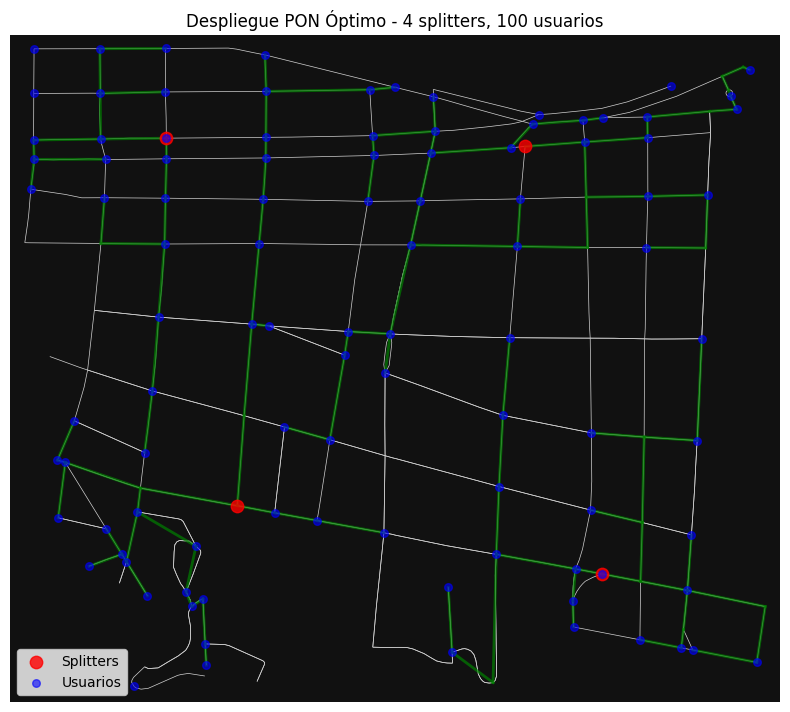

In [15]:
# ========== VISUALIZACIÓN ESTÁTICA (matplotlib) ==========
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_linewidth=0.5, edge_color='lightgray')

# Dibujar rutas de fibra instaladas (verde)
for (u,v) in installed_edges:
    xs = [G.nodes[u]['x'], G.nodes[v]['x']]
    ys = [G.nodes[u]['y'], G.nodes[v]['y']]
    ax.plot(xs, ys, color='green', linewidth=2, alpha=0.7, zorder=2)

# Dibujar splitters (rojo)
splitter_points = [Point(G.nodes[s]['x'], G.nodes[s]['y']) for s in installed_splitters]
if splitter_points:
    splitter_gdf = gpd.GeoDataFrame(geometry=splitter_points, crs=nodes_gdf.crs)
    splitter_gdf.plot(ax=ax, color='red', markersize=80, alpha=0.8, zorder=3, label='Splitters')

# Dibujar usuarios (azul)
users_gdf.plot(ax=ax, color='blue', markersize=30, alpha=0.6, zorder=3, label='Usuarios')

ax.legend()
plt.title(f'Despliegue PON Óptimo - {len(installed_splitters)} splitters, {len(users_gdf)} usuarios')
plt.tight_layout()
plt.show()


In [16]:
# ========== MAPA ILP (RUTAS OPTIMIZADAS) - Enlaces resaltados ==========
# Usar el grafo simplificado como base y destacar rutas ILP instaladas en rojo

# Reproyectar a WGS84 para folium (si no existe)
nodes_wgs84_local = nodes_gdf.to_crs(epsg=4326)
users_wgs84_local = users_gdf.to_crs(epsg=4326)

center = [users_wgs84_local.geometry.y.mean(), users_wgs84_local.geometry.x.mean()]
map_ilp = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')

# Base grafo (gris claro)
for _, edge in edges_gdf.to_crs(epsg=4326).iterrows():
    if edge.geometry is None:
        continue
    if edge.geometry.geom_type == 'MultiLineString':
        for part in edge.geometry:
            coords = [[pt[1], pt[0]] for pt in part.coords]
            folium.PolyLine(coords, color='lightgray', weight=1, opacity=0.4).add_to(map_ilp)
    elif edge.geometry.geom_type == 'LineString':
        coords = [[pt[1], pt[0]] for pt in edge.geometry.coords]
        folium.PolyLine(coords, color='lightgray', weight=1, opacity=0.4).add_to(map_ilp)

# Dibujar rutas de ILP instaladas (red - ancho mayor)
if installed_edges:
    ilp_group = folium.FeatureGroup(name='Rutas ILP (Instaladas)')
    for (u, v) in installed_edges:
        try:
            node_u = nodes_wgs84_local.loc[u]
            node_v = nodes_wgs84_local.loc[v]
            coords = [[node_u.geometry.y, node_u.geometry.x], [node_v.geometry.y, node_v.geometry.x]]
            folium.PolyLine(coords, color='red', weight=4, opacity=0.85, popup=f'Instalada: {u}->{v}').add_to(ilp_group)
        except Exception:
            continue
    ilp_group.add_to(map_ilp)

# Splitters instalados (rojo) con tooltip
splitter_group_ilp = folium.FeatureGroup(name='Splitters ILP')
for s in installed_splitters:
    node = nodes_wgs84_local.loc[s]
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    folium.Marker(location=[node.geometry.y, node.geometry.x], popup=f"Splitter {s} ({users_count} usuarios)", tooltip=f'Splitter {s}', icon=folium.Icon(color='red', icon='signal', prefix='fa')).add_to(splitter_group_ilp)
splitter_group_ilp.add_to(map_ilp)

# Usuarios (azul) - mostrados con tooltip
user_group_ilp = folium.FeatureGroup(name='Usuarios ILP')
for idx, row in users_wgs84_local.iterrows():
    assigned_splitter = next((s for (u, s) in assignments if u == idx), None)
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x], radius=4, color='blue', fill=True, fillOpacity=0.7, tooltip=f'Usuario {idx} - Splitter: {assigned_splitter}').add_to(user_group_ilp)
user_group_ilp.add_to(map_ilp)

# Añadir capa de control y guardar
folium.LayerControl().add_to(map_ilp)
plugins.Fullscreen().add_to(map_ilp)
map_ilp.save('map_rutas_ilp.html')
print('Mapa con rutas ILP guardado en: map_rutas_ilp.html')
map_ilp


Mapa con rutas ILP guardado en: map_rutas_ilp.html


In [17]:
# ========== VISUALIZACIÓN INTERACTIVA (folium) ==========
import folium
from folium import plugins

# Reproyectar a WGS84 (lat/lon) para folium
nodes_wgs84 = nodes_gdf.to_crs(epsg=4326)
users_wgs84 = users_gdf.to_crs(epsg=4326)

# Calcular centro del mapa
center = [users_wgs84.geometry.y.mean(), users_wgs84.geometry.x.mean()]

# Crear mapa base
m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')

# Capa 1: Rutas de fibra Manhattan (líneas verdes)
fiber_group = folium.FeatureGroup(name='Fibra Óptica (Rutas Manhattan)')
for (u,v) in installed_edges:
    node_u = nodes_wgs84.loc[u]
    node_v = nodes_wgs84.loc[v]
    coords = [
        [node_u.geometry.y, node_u.geometry.x],
        [node_v.geometry.y, node_v.geometry.x]
    ]
    # Calcular distancia de este segmento
    idx = get_edge_index_safe(edge_index_lookup, (u, v)) if 'edge_index_lookup' in globals() else None
    segment_length = edge_length_map.get(idx, 0) if idx is not None else 0
    
    folium.PolyLine(
        coords,
        color='green',
        weight=3,
        opacity=0.7,
        popup=f'Fibra: {u} ↔ {v}<br>Longitud: {segment_length:.1f} m'
    ).add_to(fiber_group)
fiber_group.add_to(m)

# Capa 2: Splitters (marcadores rojos)
splitter_group = folium.FeatureGroup(name='Splitters Instalados')
for s in installed_splitters:
    node = nodes_wgs84.loc[s]
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    
    # Calcular Power Budget promedio para usuarios de este splitter
    splitter_losses = [compute_optical_loss_for_path(path_lengths[(u,s)], SPLIT_RATIO) 
                       for (u, sp) in assignments if sp == s]
    avg_loss = np.mean(splitter_losses) if splitter_losses else 0
    
    folium.Marker(
        location=[node.geometry.y, node.geometry.x],
        popup=folium.Popup(
            f"<b>Splitter {s}</b><br>"
            f"Usuarios conectados: {users_count}/{SPLIT_RATIO}<br>"
            f"Utilización: {users_count/SPLIT_RATIO*100:.1f}%<br>"
            f"Pérdida óptica promedio: {avg_loss:.2f} dB<br>"
            f"Power Budget: {POWER_BUDGET_DB:.1f} dB",
            max_width=300
        ),
        tooltip=f"Splitter {s} ({users_count} usuarios)",
        icon=folium.Icon(color='red', icon='signal', prefix='fa')
    ).add_to(splitter_group)
splitter_group.add_to(m)

# Capa 3: Usuarios (marcadores azules con info de Power Budget)
user_group = folium.FeatureGroup(name='Usuarios')
for idx, row in users_wgs84.iterrows():
    assigned_splitter = next((s for (u, s) in assignments if u == idx), None)
    distance = path_lengths.get((idx, assigned_splitter), 0) if assigned_splitter else 0
    loss = compute_optical_loss_for_path(distance, SPLIT_RATIO) if assigned_splitter else 0
    margin = POWER_BUDGET_DB - loss
    latency = propagation_latency_us(distance) if assigned_splitter else 0
    
    # Color según margen de Power Budget
    if margin > 5:
        marker_color = 'darkblue'  # Excelente margen
    elif margin > 2:
        marker_color = 'blue'      # Buen margen
    elif margin > 0:
        marker_color = 'lightblue' # Margen ajustado
    else:
        marker_color = 'orange'    # Violación (no debería ocurrir)
    
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        popup=folium.Popup(
            f"<b>Usuario {idx}</b><br>"
            f"Splitter asignado: {assigned_splitter}<br>"
            f"<b>Distancia Manhattan: {distance:.1f} m</b><br>"
            f"Pérdida óptica: {loss:.2f} dB<br>"
            f"Power Budget disponible: {POWER_BUDGET_DB:.1f} dB<br>"
            f"Margen: {margin:.2f} dB<br>"
            f"Latencia: {latency:.2f} µs<br>"
            f"Cumple Power Budget: {'✓' if loss <= POWER_BUDGET_DB else '✗'}",
            max_width=300
        ),
        tooltip=f"Usuario {idx} (margen: {margin:.1f} dB)",
        color=marker_color,
        fill=True,
        fillColor=marker_color,
        fillOpacity=0.7
    ).add_to(user_group)
user_group.add_to(m)

# Agregar control de capas y pantalla completa
folium.LayerControl().add_to(m)
plugins.Fullscreen().add_to(m)

# Agregar leyenda mejorada con info de Power Budget
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 250px; height: 180px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:13px; padding: 10px">
<p><b>Leyenda - Despliegue PON</b></p>
<p><i class="fa fa-signal" style="color:red"></i> Splitters ({} instalados)</p>
<p><span style="color:blue">●</span> Usuarios ({} conectados)</p>
<p><span style="color:green">━</span> Fibra (rutas Manhattan)</p>
<p><b>Power Budget:</b> {:.1f} dB</p>
<p><b>Ratio:</b> 1:{} (max)</p>
<p style="font-size:11px; margin-top:5px"> 
<b>Color usuarios:</b><br>
● Azul oscuro: margen >5dB<br>
● Azul: margen >2dB<br>
● Azul claro: margen 0-2dB
</p>
</div>
'''.format(len(installed_splitters), len(users_gdf), POWER_BUDGET_DB, SPLIT_RATIO)
m.get_root().html.add_child(folium.Element(legend_html))

# Mostrar mapa
m

# Al final de la celda, agrega:
m.save('output/mapa_despliegue_pon.html')
print("Mapa guardado en: mapa_despliegue_pon.html")

Mapa guardado en: mapa_despliegue_pon.html


In [18]:
# ========== COMPARATIVA URBANA vs RURAL ==========
import os

def get_edge_length_safe_local(G_loc, u, v):
    ed = G_loc.get_edge_data(u, v)
    if not ed:
        return 0.0
    if isinstance(ed, dict) and all(not isinstance(vv, dict) for vv in ed.values()):
        return float(ed.get('length', 0.0))
    lengths = []
    for key, attr in ed.items():
        if isinstance(attr, dict):
            lengths.append(float(attr.get('length', 0.0)))
    if lengths:
        return min(lengths)
    return 0.0


def run_pipeline_for_area(area_key, output_subfolder, max_iterations=3, time_limit=120):
    # Setup local area config
    a_config = areas[area_key]
    print(f"\n--- Ejecutando pipeline para área: {area_key} (radio {a_config['radius']} m) ---")
    
    # Crear directorio de salida
    output_dir = os.path.join('output', output_subfolder)
    os.makedirs(output_dir, exist_ok=True)
    print(f"Directorio de salida: {output_dir}")

    # Extract graph
    G_l = ox.graph_from_point(a_config['point'], dist=a_config['radius'], network_type='drive')
    G_l = ox.project_graph(G_l)
    nodes_l, edges_l = ox.graph_to_gdfs(G_l)
    
    # 1. Guardar map_graph.html (Grafo simplificado)
    m_graph = folium.Map(location=a_config['point'], zoom_start=14, tiles='OpenStreetMap')
    folium.GeoJson(edges_l.to_crs(epsg=4326), style_function=lambda x: {'color': 'gray', 'weight': 1}).add_to(m_graph)
    m_graph.save(os.path.join(output_dir, 'map_graph.html'))
    print(f"Mapa grafo guardado en: {os.path.join(output_dir, 'map_graph.html')}")

    # Generate users
    num_users_local = a_config['num_users']
    available_nodes_l = list(nodes_l.index)
    if len(available_nodes_l) < num_users_local:
        num_users_local = len(available_nodes_l)
    user_node_ids_l = np.random.choice(available_nodes_l, size=num_users_local, replace=False)
    users_l = nodes_l.loc[user_node_ids_l, ['x','y']].copy()
    users_l['geometry'] = users_l.apply(lambda r: Point(r.x, r.y), axis=1)
    users_l = gpd.GeoDataFrame(users_l, geometry='geometry', crs=nodes_l.crs)
    users_l['node_id'] = users_l.index

    # Position splitters by clustering
    candidate_nodes_l, users_l_updated = position_splitters_by_clustering(users_l.copy(), nodes_l, G_l, n_splitters=None)

    # Calculate Manhattan paths
    local_paths, local_lengths = calculate_manhattan_paths(users_l_updated, candidate_nodes_l, G_l)

    # Validate power budget
    feasible_pairs_l = []
    for (u, s), length in local_lengths.items():
        loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
        if feasible:
            feasible_pairs_l.append((u, s))

    # If no feasible pairs, return early
    if not feasible_pairs_l:
        print('No hay pares factibles con Power Budget en esta área')
        return None

    # Build edge sets and maps
    relevant_edges_l = set()
    for (u, s) in feasible_pairs_l:
        edges = local_paths[(u, s)]
        for e in edges:
            relevant_edges_l.add(e)
    edge_keys_l = list(relevant_edges_l)
    edge_index_to_edge_l = {i: edge_keys_l[i] for i in range(len(edge_keys_l))}
    # Build undirected mapping
    edge_index_lookup_l = {}
    for i in range(len(edge_keys_l)):
        e = edge_keys_l[i]
        edge_index_lookup_l[e] = i
        edge_index_lookup_l[(e[1], e[0])] = i
    edge_length_map_l = {i: get_edge_length_safe_local(G_l, edge_index_to_edge_l[i][0], edge_index_to_edge_l[i][1]) for i in edge_index_to_edge_l.keys()}

    # Solver initial
    user_ids_l = list(users_l_updated['node_id'])
    candidate_ids_l = list(candidate_nodes_l.index)

    solution_l = solve_ilp_with_power_budget(feasible_pairs_l, local_paths, edge_keys_l, edge_length_map_l, edge_index_lookup_l, user_ids_l, candidate_ids_l, split_ratio=SPLIT_RATIO, time_limit=time_limit)

    iter_count = 0
    uncovered_users_l = solution_l['uncovered_users']
    
    # Historial de iteraciones para el mapa de rutas
    iteration_history = []
    iteration_history.append({
        'iteration': 0,
        'solution': solution_l,
        'candidate_nodes': candidate_nodes_l.copy()
    })

    # Iterative reposition of splitters
    while len(uncovered_users_l) > 0 and iter_count < max_iterations:
        iter_count += 1
        # Add splitters for uncovered
        candidate_nodes_l = add_splitters_for_uncovered_users(uncovered_users_l, users_l_updated, nodes_l, candidate_nodes_l, G_l)
        candidate_ids_l = list(candidate_nodes_l.index)
        # Recalculate routes
        new_paths, new_lengths = calculate_manhattan_paths(users_l_updated, candidate_nodes_l, G_l)
        local_paths.update(new_paths)
        local_lengths.update(new_lengths)
        # Revalidate feasible pairs
        feasible_pairs_l = []
        for (u, s), length in local_lengths.items():
            loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
            if feasible:
                feasible_pairs_l.append((u, s))
        # Rebuild edges and edge maps
        relevant_edges_l = set()
        for (u, s) in feasible_pairs_l:
            if (u, s) in local_paths:
                for e in local_paths[(u, s)]:
                    relevant_edges_l.add(e)
        edge_keys_l = list(relevant_edges_l)
        edge_index_to_edge_l = {i: edge_keys_l[i] for i in range(len(edge_keys_l))}
        edge_index_lookup_l = {}
        for i in range(len(edge_keys_l)):
            e = edge_keys_l[i]
            edge_index_lookup_l[e] = i
            edge_index_lookup_l[(e[1], e[0])] = i
        edge_length_map_l = {i: get_edge_length_safe_local(G_l, edge_index_to_edge_l[i][0], edge_index_to_edge_l[i][1]) for i in edge_index_to_edge_l.keys()}

        # Re-solve ILP
        solution_l = solve_ilp_with_power_budget(feasible_pairs_l, local_paths, edge_keys_l, edge_length_map_l, edge_index_lookup_l, user_ids_l, candidate_ids_l, split_ratio=SPLIT_RATIO, time_limit=time_limit)
        
        iteration_history.append({
            'iteration': iter_count,
            'solution': solution_l,
            'candidate_nodes': candidate_nodes_l.copy()
        })

        uncovered_users_l = solution_l['uncovered_users']

    # Final solution
    final_sol = iteration_history[-1]['solution']
    assignments_l = final_sol['assignments']
    installed_splitters_l = final_sol['installed_splitters']
    installed_edges_l = final_sol['installed_edges']

    # 2. Generar map_rutas.html (Todas las iteraciones)
    print("Generando map_rutas.html...")
    m_rutas = folium.Map(location=a_config['point'], zoom_start=14, tiles='OpenStreetMap')
    colors = ['blue', 'green', 'purple', 'orange', 'red', 'darkblue']
    
    nodes_wgs84 = nodes_l.to_crs(epsg=4326)
    
    for i, hist in enumerate(iteration_history):
        sol = hist['solution']
        inst_edges = sol['installed_edges']
        layer_name = f"Iteración {hist['iteration']} (Cob: {len(sol['assignments'])}/{len(user_ids_l)})"
        
        fg = folium.FeatureGroup(name=layer_name, show=(i == len(iteration_history)-1))
        
        for u, v in inst_edges:
            try:
                p1 = (nodes_wgs84.loc[u].geometry.y, nodes_wgs84.loc[u].geometry.x)
                p2 = (nodes_wgs84.loc[v].geometry.y, nodes_wgs84.loc[v].geometry.x)
                folium.PolyLine([p1, p2], color=colors[i % len(colors)], weight=2, opacity=0.7).add_to(fg)
            except: pass
        fg.add_to(m_rutas)
        
    folium.LayerControl().add_to(m_rutas)
    m_rutas.save(os.path.join(output_dir, 'map_rutas.html'))
    print(f"Mapa rutas guardado en: {os.path.join(output_dir, 'map_rutas.html')}")

    # 3. Generar map_despliegue_pon.html (Final)
    details = {
        'nodes': nodes_l,
        'edges': edges_l,
        'installed_edges': installed_edges_l,
        'installed_splitters': installed_splitters_l,
        'assignments': assignments_l,
        'users': users_l_updated,
        'path_lengths': local_lengths,
        'edge_index_lookup': edge_index_lookup_l,
        'edge_length_map': edge_length_map_l
    }
    save_interactive_map_from_details(details, os.path.join(output_dir, 'mapa_despliegue_pon.html'))

    # 4. Guardar CSVs
    results_summary = {
        'area_type': area_key,
        'num_users': len(user_ids_l),
        'num_splitters': len(installed_splitters_l),
        'num_assignments': len(assignments_l),
        'coverage_pct': len(assignments_l)/len(user_ids_l)*100 if len(user_ids_l) > 0 else 0,
        'total_cost': final_sol['cost'],
        'iterations': iter_count
    }
    pd.DataFrame([results_summary]).to_csv(os.path.join(output_dir, 'resultados.csv'), index=False)
    
    if assignments_l:
        assign_data = []
        for u, s in assignments_l:
            l = local_lengths.get((u,s), 0)
            loss = compute_optical_loss_for_path(l, SPLIT_RATIO)
            assign_data.append({
                'user_id': u, 
                'splitter_id': s, 
                'distance_m': l,
                'loss_db': loss
            })
        pd.DataFrame(assign_data).to_csv(os.path.join(output_dir, 'asignaciones.csv'), index=False)

    return {'metrics': results_summary, 'details': details}


In [19]:
# ========== MÉTRICAS DEL DESPLIEGUE ==========
# Calcular utilización de splitters
splitter_usage = {}
for s in installed_splitters:
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    splitter_usage[s] = users_count

avg_utilization = np.mean(list(splitter_usage.values())) / SPLIT_RATIO * 100

# Calcular costo total
# Use safe lookup for edge indices
total_fiber_length = 0.0
missing_edges = []
for e in installed_edges:
    idx = get_edge_index_safe(edge_index_lookup, e)
    if idx is not None:
        total_fiber_length += edge_length_map.get(idx, 0)
    else:
        missing_edges.append(e)
if missing_edges:
    print(f"ADVERTENCIA: {len(missing_edges)} aristas instaladas no tienen índice conocido y fueron ignoradas en costo: {missing_edges[:10]}")

total_cost = total_fiber_length * COST_FIBER_PER_M + len(installed_splitters) * COST_SPLITTER

# Calcular estadísticas de pérdida óptica
optical_losses = [compute_optical_loss_for_path(path_lengths[(u,s)], SPLIT_RATIO) for (u,s) in assignments]
max_loss = max(optical_losses)
avg_loss = np.mean(optical_losses)

print("=" * 60)
print("RESUMEN DEL DESPLIEGUE PON ÓPTIMO")
print("=" * 60)
print(f"Splitters instalados:        {len(installed_splitters)}")
print(f"Usuarios conectados:         {len(users_gdf)}")
print(f"Utilización promedio:        {avg_utilization:.1f}%")
print(f"Fibra total instalada:       {total_fiber_length:.1f} m ({total_fiber_length/1000:.2f} km)")
print(f"Costo total estimado:        {total_cost:.2f} unidades")
print(f"Pérdida óptica promedio:     {avg_loss:.2f} dB")
print(f"Pérdida óptica máxima:       {max_loss:.2f} dB")
print(f"Cumple Power Budget ({POWER_BUDGET_DB:.0f} dB): {'SÍ' if max_loss <= POWER_BUDGET_DB else 'NO'}")
print("=" * 60)

RESUMEN DEL DESPLIEGUE PON ÓPTIMO
Splitters instalados:        4
Usuarios conectados:         100
Utilización promedio:        74.2%
Fibra total instalada:       7510.6 m (7.51 km)
Costo total estimado:        8310.61 unidades
Pérdida óptica promedio:     18.62 dB
Pérdida óptica máxima:       18.79 dB
Cumple Power Budget (30 dB): SÍ


## 12. Conclusiones y mejoras implementadas

### Cambios principales implementados según feedback del profesor:

1. **Áreas de estudio redefinidas**:
   - Se abandonó el enfoque de toda la ciudad de Valparaíso
   - Se implementaron 3 tipos de áreas: Urbana, Semi-Urbana y Rural
   - Cada área tiene características específicas de densidad y radio

2. **Posicionamiento de splitters basado en usuarios**:
   - **Antes**: Selección por intersecciones con alta conectividad
   - **Ahora**: Clustering (K-Means) de usuarios para determinar posiciones óptimas
   - Los splitters se ubican en nodos viales cercanos a centroides de clusters
   - Garantiza que los splitters estén cerca de grupos de usuarios reales

3. **Rutas con distancia Manhattan**:
   - Se mantiene el enfoque de rutas siguiendo calles reales
   - Optimizado con Numba para manejar grandes volúmenes de datos

4. **Proceso iterativo con Power Budget**:
   - **Antes**: ILP decide ubicación de splitters y asignaciones simultáneamente
   - **Ahora**: 
     - Los splitters se posicionan primero (clustering)
     - Se valida Power Budget antes del ILP
     - El ILP solo decide asignaciones óptimas
     - Si hay usuarios sin cobertura, se agregan splitters y se repite el proceso
   - Garantiza que todos los usuarios tengan cobertura (o se maximice la cobertura)

5. **Optimización con Numba**:
   - Funciones críticas decoradas con `@jit(nopython=True)`
   - Cálculos de distancia y Power Budget acelerados
   - Permite procesar datasets grandes sin problemas de rendimiento

### Ventajas del nuevo enfoque:

- **Escalabilidad**: Numba permite procesar miles de usuarios sin degradación
- **Realismo**: Splitters posicionados según ubicación real de usuarios
- **Cobertura garantizada**: Proceso iterativo asegura que todos los usuarios tengan servicio
- **Eficiencia**: ILP simplificado (menos variables de decisión) se resuelve más rápido
- **Flexibilidad**: Fácil adaptar a diferentes escenarios (urbano/rural)

### Arquitectura del flujo de trabajo:

```
1. Seleccionar área (urbana/semi-urbana/rural)
2. Extraer topología con OSMnx
3. Generar usuarios
4. Posicionar splitters (clustering)
    ↓
5. Calcular rutas Manhattan
6. Validar Power Budget
7. Resolver ILP
    ↓
8. ¿Todos cubiertos? → NO → Agregar splitters → Volver a paso 5
    ↓ SÍ
9. Validación final
10. Visualización
```

### Métricas clave del diseño:

- **Cobertura**: % de usuarios con servicio
- **Power Budget**: Todas las rutas cumplen requisitos ópticos
- **Eficiencia**: Utilización promedio de splitters
- **Costo**: Minimizado por ILP
- **Latencia**: Dentro de rangos aceptables para GPON

### Posibles extensiones futuras:

- Topología multi-nivel (cascada de splitters)
- Múltiples OLTs para áreas grandes
- Consideración de diferentes clases de servicio
- Análisis de resiliencia y redundancia
- Optimización multi-objetivo (costo vs. latencia)

## Guía de uso del notebook

### Selección de área de estudio:

En la celda de configuración, modificar la variable `AREA_TYPE`:

```python
AREA_TYPE = 'urbana'  # Opciones: 'urbana', 'semi_urbana', 'rural'
```

### Parámetros ajustables:

**Económicos:**
- `COST_FIBER_PER_M`: Costo por metro de fibra
- `COST_SPLITTER`: Costo de instalación de splitter
- `SPLIT_RATIO`: Capacidad máxima (usuarios por splitter)

**Power Budget:**
- `TX_POWER_DBM`: Potencia transmitida por OLT
- `RX_SENSITIVITY_DBM`: Sensibilidad del receptor ONU
- `SYSTEM_MARGIN_DB`: Margen de sistema

**Iteración:**
- `MAX_ITERATIONS`: Máximo de iteraciones para reposicionamiento
- `MIN_COVERAGE`: Cobertura mínima requerida (0.95 = 95%)

### Interpretación de visualizaciones:

**Mapa estático:**
- Líneas grises: Red vial
- Líneas verdes: Fibra instalada (rutas Manhattan)
- Puntos rojos: Splitters
- Puntos azules: Usuarios

**Mapa interactivo:**
- Click en marcadores para detalles
- Información de Power Budget por usuario
- Utilización de cada splitter
- Latencias y distancias

### Flujo de ejecución:

1. Ejecutar celdas en orden secuencial
2. El proceso iterativo se ejecuta automáticamente
3. Si no se alcanza cobertura completa en MAX_ITERATIONS, revisar:
   - Aumentar `POWER_BUDGET_DB`
   - Reducir `SPLIT_RATIO`
   - Ajustar área de estudio (radio menor)

### Optimización del rendimiento:

- Numba compila funciones en la primera ejecución (puede tardar)
- Ejecuciones posteriores son mucho más rápidas
- Para datasets muy grandes (>500 usuarios), considerar aumentar `time_limit` del ILP

## 13. Procesamiento de escenarios: Urbano, Semi-Urbano y Rural

A continuación se procesarán los tres escenarios de forma secuencial, guardando todos los resultados en directorios organizados dentro de `output/`.

Cada escenario generará:
- `map_raw.html`: Mapa del área seleccionada
- `mapa_despliegue_pon.html`: Mapa con el diseño óptimo final
- `resultados.csv`: Resumen de métricas
- `asignaciones.csv`: Detalle de asignaciones usuario-splitter

In [20]:
# ========== FUNCIÓN AUXILIAR: Guardar mapa RAW del área ==========
import os

def save_raw_map_for_area(area_point, area_radius, area_name, output_dir):
    """Genera y guarda el mapa RAW (sin simplificar) de un área."""
    
    # Descargar grafo crudo
    G_raw_local = ox.graph_from_point(area_point, dist=area_radius, network_type='drive', simplify=False)
    nodes_raw_local, edges_raw_local = ox.graph_to_gdfs(G_raw_local)
    nodes_raw_wgs84_local = nodes_raw_local.to_crs(epsg=4326)
    edges_raw_wgs84_local = edges_raw_local.to_crs(epsg=4326)
    
    if nodes_raw_wgs84_local.empty or edges_raw_wgs84_local.empty:
        print(f'  Advertencia: Red cruda vacía para {area_name}')
        return
    
    # Crear mapa
    map_raw_local = folium.Map(
        location=[nodes_raw_wgs84_local.geometry.y.mean(), nodes_raw_wgs84_local.geometry.x.mean()],
        zoom_start=15
    )
    
    # Dibujar red
    for _, edge in edges_raw_wgs84_local.iterrows():
        if edge.geometry is None:
            continue
        if edge.geometry.geom_type == 'MultiLineString':
            for part in edge.geometry:
                coords = [[pt[1], pt[0]] for pt in part.coords]
                folium.PolyLine(coords, color='lightgray', weight=1, opacity=0.4).add_to(map_raw_local)
        elif edge.geometry.geom_type == 'LineString':
            coords = [[pt[1], pt[0]] for pt in edge.geometry.coords]
            folium.PolyLine(coords, color='lightgray', weight=1, opacity=0.4).add_to(map_raw_local)
    
    # Círculo y marcador central
    folium.Circle(
        location=[area_point[0], area_point[1]], 
        radius=area_radius, 
        color='blue', 
        fill=False, 
        popup=f"Área: {area_name}"
    ).add_to(map_raw_local)
    
    folium.Marker(
        location=[area_point[0], area_point[1]], 
        popup=f'Centro del área {area_name}',
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(map_raw_local)
    
    # Leyenda
    legend_raw_local = f"""
    <div style="position: fixed; bottom: 50px; right: 50px; width: 200px; background-color: white; border:2px solid grey; z-index:9999; font-size:12px; padding: 10px">
    <b>Mapa OSM - {area_name}</b><br>
    - Red cruda (sin simplificar)<br>
    - Centro: {area_point}<br>
    - Radio: {area_radius} m
    </div>
    """
    map_raw_local.get_root().html.add_child(folium.Element(legend_raw_local))
    
    # Guardar
    output_path = os.path.join(output_dir, 'map_raw.html')
    map_raw_local.save(output_path)
    print(f'  ✓ Mapa RAW guardado: {output_path}')
    

print("Función auxiliar definida: save_raw_map_for_area()")


Función auxiliar definida: save_raw_map_for_area()


In [21]:
# ========== FUNCIÓN AUXILIAR: Guardar mapa de despliegue PON ==========

def save_interactive_map_from_details(details, filename='mapa_despliegue_pon.html'):
    """Genera y guarda el mapa interactivo con el diseño final PON."""
    
    nodes_gdf_local = details['nodes']
    edges_gdf_local = details['edges']
    installed_edges_local = details['installed_edges']
    installed_splitters_local = details['installed_splitters']
    assignments_local = details['assignments']
    users_gdf_local = details['users']
    path_lengths_local = details['path_lengths']
    edge_index_lookup_local = details.get('edge_index_lookup', {})
    edge_length_map_local = details.get('edge_length_map', {})

    nodes_wgs84_local = nodes_gdf_local.to_crs(epsg=4326)
    users_wgs84_local = users_gdf_local.to_crs(epsg=4326)
    
    if len(users_wgs84_local) == 0:
        center = [nodes_wgs84_local.geometry.y.mean(), nodes_wgs84_local.geometry.x.mean()]
    else:
        center = [users_wgs84_local.geometry.y.mean(), users_wgs84_local.geometry.x.mean()]

    m_local = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')

    # Fibra óptica
    fiber_group_local = folium.FeatureGroup(name='Fibra Óptica (Rutas Manhattan)')
    for (u, v) in installed_edges_local:
        try:
            node_u_local = nodes_wgs84_local.loc[u]
            node_v_local = nodes_wgs84_local.loc[v]
            coords = [
                [node_u_local.geometry.y, node_u_local.geometry.x],
                [node_v_local.geometry.y, node_v_local.geometry.x]
            ]
            idx = get_edge_index_safe(edge_index_lookup_local, (u, v)) if edge_index_lookup_local else None
            segment_length = edge_length_map_local.get(idx, 0) if idx is not None else 0
            folium.PolyLine(
                coords, color='green', weight=3, opacity=0.7,
                popup=f'Fibra: {u} ↔ {v}<br>Longitud: {segment_length:.1f} m'
            ).add_to(fiber_group_local)
        except:
            continue
    fiber_group_local.add_to(m_local)

    # Splitters
    splitter_group_local = folium.FeatureGroup(name='Splitters Instalados')
    for s in installed_splitters_local:
        try:
            node_local = nodes_wgs84_local.loc[s]
            users_count = sum(1 for (u, sp) in assignments_local if sp == s)
            splitter_losses = [
                compute_optical_loss_for_path(path_lengths_local[(u, s)], SPLIT_RATIO) 
                for (u, sp) in assignments_local if sp == s
            ]
            avg_loss = np.mean(splitter_losses) if splitter_losses else 0
            
            folium.Marker(
                location=[node_local.geometry.y, node_local.geometry.x],
                popup=folium.Popup(
                    f"<b>Splitter {s}</b><br>"
                    f"Usuarios: {users_count}/{SPLIT_RATIO}<br>"
                    f"Utilización: {users_count/SPLIT_RATIO*100:.1f}%<br>"
                    f"Pérdida promedio: {avg_loss:.2f} dB",
                    max_width=300
                ),
                tooltip=f"Splitter {s} ({users_count} usuarios)",
                icon=folium.Icon(color='red', icon='signal', prefix='fa')
            ).add_to(splitter_group_local)
        except:
            continue
    splitter_group_local.add_to(m_local)

    # Usuarios
    user_group_local = folium.FeatureGroup(name='Usuarios')
    for idx, row in users_wgs84_local.iterrows():
        try:
            assigned_splitter = next((s for (u, s) in assignments_local if u == idx), None)
            distance = path_lengths_local.get((idx, assigned_splitter), 0) if assigned_splitter else 0
            loss = compute_optical_loss_for_path(distance, SPLIT_RATIO) if assigned_splitter else 0
            margin = POWER_BUDGET_DB - loss
            latency = propagation_latency_us(distance) if assigned_splitter else 0
            
            if margin > 5:
                marker_color = 'darkblue'
            elif margin > 2:
                marker_color = 'blue'
            elif margin > 0:
                marker_color = 'lightblue'
            else:
                marker_color = 'orange'
            
            folium.CircleMarker(
                location=[row.geometry.y, row.geometry.x],
                radius=5,
                popup=folium.Popup(
                    f"<b>Usuario {idx}</b><br>"
                    f"Splitter: {assigned_splitter}<br>"
                    f"Distancia: {distance:.1f} m<br>"
                    f"Pérdida: {loss:.2f} dB<br>"
                    f"Margen: {margin:.2f} dB<br>"
                    f"Latencia: {latency:.2f} µs",
                    max_width=300
                ),
                tooltip=f"Usuario {idx}",
                color=marker_color,
                fill=True,
                fillColor=marker_color,
                fillOpacity=0.7
            ).add_to(user_group_local)
        except:
            continue
    user_group_local.add_to(m_local)

    folium.LayerControl().add_to(m_local)
    plugins.Fullscreen().add_to(m_local)

    # Leyenda
    legend_html = f'''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 250px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:13px; padding: 10px">
<p><b>Despliegue PON</b></p>
<p><i class="fa fa-signal" style="color:red"></i> Splitters ({len(installed_splitters_local)})</p>
<p><span style="color:blue">●</span> Usuarios ({len(users_gdf_local)})</p>
<p><span style="color:green">━</span> Fibra</p>
<p><b>Power Budget:</b> {POWER_BUDGET_DB:.1f} dB</p>
</div>
'''
    m_local.get_root().html.add_child(folium.Element(legend_html))

    m_local.save(filename)
    print(f'  ✓ Mapa de despliegue guardado: {filename}')


print("Función auxiliar definida: save_interactive_map_from_details()")


Función auxiliar definida: save_interactive_map_from_details()


In [22]:
# ========== FUNCIÓN: Procesar un escenario completo ==========

def process_scenario(area_key, output_subfolder, max_iterations=5, time_limit=120):
    """
    Procesa un escenario completo: extrae red, calcula splitters, resuelve ILP y guarda resultados.
    
    Returns:
        dict con métricas del escenario
    """
    import os
    
    a_config = areas[area_key]
    output_dir = os.path.join('output', output_subfolder)
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n{'='*70}")
    print(f"PROCESANDO ESCENARIO: {area_key.upper()}")
    print(f"{'='*70}")
    print(f"Descripción: {a_config['description']}")
    print(f"Radio: {a_config['radius']} m")
    print(f"Usuarios esperados: {a_config['num_users']}")
    print(f"Directorio de salida: {output_dir}")
    
    # 1. Guardar mapa RAW
    print(f"\n[1/5] Generando mapa RAW...")
    save_raw_map_for_area(a_config['point'], a_config['radius'], area_key, output_dir)
    
    # 2. Extraer grafo
    print(f"\n[2/5] Extrayendo topología de OpenStreetMap...")
    G_local = ox.graph_from_point(a_config['point'], dist=a_config['radius'], network_type='drive')
    G_local = ox.project_graph(G_local)
    nodes_local, edges_local = ox.graph_to_gdfs(G_local)
    print(f"  ✓ Nodos: {len(nodes_local)}, Aristas: {len(edges_local)}")
    
    # 3. Generar usuarios
    print(f"\n[3/5] Generando usuarios...")
    num_users_local = a_config['num_users']
    available_nodes_local = list(nodes_local.index)
    if len(available_nodes_local) < num_users_local:
        num_users_local = len(available_nodes_local)
    
    user_node_ids_local = np.random.choice(available_nodes_local, size=num_users_local, replace=False)
    users_local = nodes_local.loc[user_node_ids_local, ['x', 'y']].copy()
    users_local['geometry'] = users_local.apply(lambda r: Point(r.x, r.y), axis=1)
    users_local = gpd.GeoDataFrame(users_local, geometry='geometry', crs=nodes_local.crs)
    users_local['node_id'] = users_local.index
    print(f"  ✓ Usuarios generados: {len(users_local)}")
    
    # 4. Posicionar splitters
    print(f"\n[4/5] Posicionando splitters por clustering...")
    candidate_nodes_local, users_local = position_splitters_by_clustering(users_local, nodes_local, G_local)
    user_ids_local = list(users_local['node_id'])
    candidate_ids_local = list(candidate_nodes_local.index)
    print(f"  ✓ Splitters candidatos: {len(candidate_nodes_local)}")
    
    # 5. Calcular rutas Manhattan y validar Power Budget
    print(f"\n[5/5] Calculando rutas y resolviendo ILP...")
    local_paths, local_lengths = calculate_manhattan_paths(users_local, candidate_nodes_local, G_local)
    
    # Validar Power Budget
    feasible_pairs_local = []
    for (u, s), length in local_lengths.items():
        loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
        if feasible:
            feasible_pairs_local.append((u, s))
    
    if not feasible_pairs_local:
        print('  ✗ No hay pares factibles con Power Budget')
        return None
    
    # Construir estructuras para ILP
    relevant_edges_local = set()
    for (u, s) in feasible_pairs_local:
        for e in local_paths[(u, s)]:
            relevant_edges_local.add(e)
    
    edge_keys_local = list(relevant_edges_local)
    edge_index_to_edge_local = {i: edge_keys_local[i] for i in range(len(edge_keys_local))}
    edge_index_lookup_local = {}
    for i in range(len(edge_keys_local)):
        e = edge_keys_local[i]
        edge_index_lookup_local[e] = i
        edge_index_lookup_local[(e[1], e[0])] = i
    
    edge_length_map_local = {
        i: get_edge_length_safe(G_local, edge_index_to_edge_local[i][0], edge_index_to_edge_local[i][1])
        for i in edge_index_to_edge_local.keys()
    }
    
    # Resolver ILP inicial
    solution_local = solve_ilp_with_power_budget(
        feasible_pairs_local, local_paths, edge_keys_local, edge_length_map_local,
        edge_index_lookup_local, user_ids_local, candidate_ids_local, time_limit=time_limit
    )
    
    assignments_local = solution_local['assignments']
    installed_splitters_local = solution_local['installed_splitters']
    installed_edges_local = solution_local['installed_edges']
    uncovered_users_local = solution_local['uncovered_users']
    
    # Bucle iterativo para usuarios sin cobertura
    iter_count = 0
    while len(uncovered_users_local) > 0 and iter_count < max_iterations:
        iter_count += 1
        print(f"\n  Iteración {iter_count}: Agregando splitters para {len(uncovered_users_local)} usuarios sin cobertura...")
        
        candidate_nodes_local = add_splitters_for_uncovered_users(
            uncovered_users_local, users_local, nodes_local, candidate_nodes_local, G_local
        )
        candidate_ids_local = list(candidate_nodes_local.index)
        
        new_paths, new_lengths = calculate_manhattan_paths(users_local, candidate_nodes_local, G_local)
        local_paths.update(new_paths)
        local_lengths.update(new_lengths)
        
        feasible_pairs_local = []
        for (u, s), length in local_lengths.items():
            loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
            if feasible:
                feasible_pairs_local.append((u, s))
        
        relevant_edges_local = set()
        for (u, s) in feasible_pairs_local:
            if (u, s) in local_paths:
                for e in local_paths[(u, s)]:
                    relevant_edges_local.add(e)
        
        edge_keys_local = list(relevant_edges_local)
        edge_index_to_edge_local = {i: edge_keys_local[i] for i in range(len(edge_keys_local))}
        edge_index_lookup_local = {}
        for i in range(len(edge_keys_local)):
            e = edge_keys_local[i]
            edge_index_lookup_local[e] = i
            edge_index_lookup_local[(e[1], e[0])] = i
        
        edge_length_map_local = {
            i: get_edge_length_safe(G_local, edge_index_to_edge_local[i][0], edge_index_to_edge_local[i][1])
            for i in edge_index_to_edge_local.keys()
        }
        
        solution_local = solve_ilp_with_power_budget(
            feasible_pairs_local, local_paths, edge_keys_local, edge_length_map_local,
            edge_index_lookup_local, user_ids_local, candidate_ids_local, time_limit=time_limit
        )
        
        assignments_local = solution_local['assignments']
        installed_splitters_local = solution_local['installed_splitters']
        installed_edges_local = solution_local['installed_edges']
        uncovered_users_local = solution_local['uncovered_users']
    
    # Calcular métricas finales
    coverage_pct = len(assignments_local) / len(user_ids_local) * 100 if len(user_ids_local) > 0 else 0
    
    total_fiber_length_local = 0.0
    for e in installed_edges_local:
        idx = get_edge_index_safe(edge_index_lookup_local, e)
        if idx is not None:
            total_fiber_length_local += edge_length_map_local.get(idx, 0)
    
    total_cost_local = total_fiber_length_local * COST_FIBER_PER_M + len(installed_splitters_local) * COST_SPLITTER
    
    losses_local = [compute_optical_loss_for_path(local_lengths[(u, s)], SPLIT_RATIO) for (u, s) in assignments_local]
    avg_loss_local = np.mean(losses_local) if losses_local else 0
    max_loss_local = np.max(losses_local) if losses_local else 0
    
    latencies_local = [propagation_latency_us(local_lengths[(u, s)]) for (u, s) in assignments_local]
    avg_latency_local = np.mean(latencies_local) if latencies_local else 0
    
    # Guardar mapa de despliegue PON
    print(f"\nGenerando mapa de despliegue PON...")
    details_local = {
        'nodes': nodes_local,
        'edges': edges_local,
        'installed_edges': installed_edges_local,
        'installed_splitters': installed_splitters_local,
        'assignments': assignments_local,
        'users': users_local,
        'path_lengths': local_lengths,
        'edge_index_lookup': edge_index_lookup_local,
        'edge_length_map': edge_length_map_local
    }
    save_interactive_map_from_details(details_local, os.path.join(output_dir, 'mapa_despliegue_pon.html'))
    
    # Guardar CSVs
    print(f"\nGuardando resultados en CSV...")
    results_summary_local = {
        'escenario': area_key,
        'descripcion': a_config['description'],
        'num_usuarios': len(user_ids_local),
        'num_splitters': len(installed_splitters_local),
        'cobertura_pct': coverage_pct,
        'fibra_total_m': total_fiber_length_local,
        'costo_total': total_cost_local,
        'perdida_promedio_db': avg_loss_local,
        'perdida_maxima_db': max_loss_local,
        'latencia_promedio_us': avg_latency_local,
        'iteraciones': iter_count
    }
    pd.DataFrame([results_summary_local]).to_csv(os.path.join(output_dir, 'resultados.csv'), index=False)
    
    if assignments_local:
        assign_data_local = []
        for u, s in assignments_local:
            l = local_lengths.get((u, s), 0)
            loss = compute_optical_loss_for_path(l, SPLIT_RATIO)
            assign_data_local.append({
                'user_id': u,
                'splitter_id': s,
                'distance_m': l,
                'loss_db': loss
            })
        pd.DataFrame(assign_data_local).to_csv(os.path.join(output_dir, 'asignaciones.csv'), index=False)
    
    print(f"\n{'='*70}")
    print(f"ESCENARIO {area_key.upper()} COMPLETADO")
    print(f"  Cobertura: {coverage_pct:.1f}%")
    print(f"  Splitters: {len(installed_splitters_local)}")
    print(f"  Costo total: {total_cost_local:.2f}")
    print(f"{'='*70}")
    
    return results_summary_local


print("Función definida: process_scenario()")


Función definida: process_scenario()


### 13.1. Escenario Urbano (Valparaíso Centro)

Procesamiento completo del escenario urbano, incluyendo:
- Extracción de topología
- Generación de usuarios
- Posicionamiento de splitters
- Cálculo de rutas y validación de Power Budget
- Resolución del ILP con proceso iterativo
- Generación de mapas y archivos de resultados

In [23]:
# Procesar escenario urbano
resultado_urbano = process_scenario('urbana', 'urbano', max_iterations=5, time_limit=120)


PROCESANDO ESCENARIO: URBANA
Descripción: Zona urbana densa - Centro Valparaíso
Radio: 500 m
Usuarios esperados: 100
Directorio de salida: output\urbano

[1/5] Generando mapa RAW...
  ✓ Mapa RAW guardado: output\urbano\map_raw.html

[2/5] Extrayendo topología de OpenStreetMap...
  ✓ Nodos: 135, Aristas: 290

[3/5] Generando usuarios...
  ✓ Usuarios generados: 100

[4/5] Posicionando splitters por clustering...
Calculando 4 posiciones de splitters para 100 usuarios...
  Cluster 0: 28 usuarios → Splitter en nodo 579628072
  Cluster 1: 24 usuarios → Splitter en nodo 259210829
  Cluster 2: 20 usuarios → Splitter en nodo 5316795923
  Cluster 3: 28 usuarios → Splitter en nodo 1528876146
  ✓ Splitters candidatos: 4

[5/5] Calculando rutas y resolviendo ILP...
Calculando rutas Manhattan para 100 usuarios y 4 splitters...
Rutas calculadas: 384/400 (96.0%)
Advertencia: 16 pares no tienen conectividad (posibles islas en el grafo o nodos desconectados).

FORMULANDO Y RESOLVIENDO ILP
Usuarios: 100

### 13.2. Escenario Semi-Urbano (Viña del Mar)

In [24]:
# Procesar escenario semi-urbano
resultado_semi_urbano = process_scenario('semi_urbana', 'semi_urbano', max_iterations=5, time_limit=120)


PROCESANDO ESCENARIO: SEMI_URBANA
Descripción: Zona semi-urbana - Viña del Mar
Radio: 800 m
Usuarios esperados: 60
Directorio de salida: output\semi_urbano

[1/5] Generando mapa RAW...


  ✓ Mapa RAW guardado: output\semi_urbano\map_raw.html

[2/5] Extrayendo topología de OpenStreetMap...
  ✓ Nodos: 410, Aristas: 741

[3/5] Generando usuarios...
  ✓ Usuarios generados: 60

[4/5] Posicionando splitters por clustering...
Calculando 2 posiciones de splitters para 60 usuarios...
  Cluster 0: 29 usuarios → Splitter en nodo 255226991
  Cluster 1: 31 usuarios → Splitter en nodo 254516069
  ✓ Splitters candidatos: 2

[5/5] Calculando rutas y resolviendo ILP...
Calculando rutas Manhattan para 60 usuarios y 2 splitters...
Rutas calculadas: 112/120 (93.3%)
Advertencia: 8 pares no tienen conectividad (posibles islas en el grafo o nodos desconectados).

FORMULANDO Y RESOLVIENDO ILP
Usuarios: 60
Splitters candidatos: 2
Pares factibles (Power Budget): 112
Aristas relevantes: 239
ADVERTENCIA: Usuario 13051695320 no tiene splitters factibles
ADVERTENCIA: Usuario 13051695309 no tiene splitters factibles
ADVERTENCIA: Usuario 252683348 no tiene splitters factibles
ADVERTENCIA: Usuario 130

### 13.3. Escenario Rural (Quilpué)

In [25]:
# Procesar escenario rural
resultado_rural = process_scenario('rural', 'rural', max_iterations=5, time_limit=120)


PROCESANDO ESCENARIO: RURAL
Descripción: Zona rural - Quilpué
Radio: 1200 m
Usuarios esperados: 30
Directorio de salida: output\rural

[1/5] Generando mapa RAW...
  ✓ Mapa RAW guardado: output\rural\map_raw.html

[2/5] Extrayendo topología de OpenStreetMap...
  ✓ Nodos: 845, Aristas: 2040

[3/5] Generando usuarios...
  ✓ Usuarios generados: 30

[4/5] Posicionando splitters por clustering...
Calculando 1 posiciones de splitters para 30 usuarios...
  Cluster 0: 30 usuarios → Splitter en nodo 4825448440
  ✓ Splitters candidatos: 1

[5/5] Calculando rutas y resolviendo ILP...
Calculando rutas Manhattan para 30 usuarios y 1 splitters...
Rutas calculadas: 30/30 (100.0%)

FORMULANDO Y RESOLVIENDO ILP
Usuarios: 30
Splitters candidatos: 1
Pares factibles (Power Budget): 30
Aristas relevantes: 194

Resolviendo ILP (límite: 120s)...

Estado de la solución: Optimal

Splitters instalados: 1
Aristas de fibra: 194
Usuarios asignados: 30/30
Usuarios sin cobertura: 0
Costo total: 16031.49

Generando m

### 13.4. Tabla Comparativa de los Tres Escenarios

Resumen consolidado de las métricas clave de cada escenario.

In [26]:
# Crear tabla comparativa
resultados_consolidados = []

if resultado_urbano:
    resultados_consolidados.append(resultado_urbano)
if resultado_semi_urbano:
    resultados_consolidados.append(resultado_semi_urbano)
if resultado_rural:
    resultados_consolidados.append(resultado_rural)

if resultados_consolidados:
    df_comparativa = pd.DataFrame(resultados_consolidados)
    
    # Reordenar y formatear columnas
    columnas_orden = [
        'escenario', 'descripcion', 'num_usuarios', 'num_splitters', 
        'cobertura_pct', 'fibra_total_m', 'costo_total', 
        'perdida_promedio_db', 'perdida_maxima_db', 
        'latencia_promedio_us', 'iteraciones'
    ]
    df_comparativa = df_comparativa[columnas_orden]
    
    # Guardar CSV en output/
    output_comp_path = 'output/comparativa_escenarios.csv'
    df_comparativa.to_csv(output_comp_path, index=False)
    print(f"✓ Tabla comparativa guardada en: {output_comp_path}")
    
    # Mostrar tabla
    print(f"\n{'='*100}")
    print("TABLA COMPARATIVA - RESUMEN DE LOS 3 ESCENARIOS")
    print(f"{'='*100}")
    print(df_comparativa.to_string(index=False))
    print(f"{'='*100}")
    
    # Mostrar tabla estilizada
    df_comparativa
else:
    print("No se pudieron generar resultados para ningún escenario.")


✓ Tabla comparativa guardada en: output/comparativa_escenarios.csv

TABLA COMPARATIVA - RESUMEN DE LOS 3 ESCENARIOS
  escenario                           descripcion  num_usuarios  num_splitters  cobertura_pct  fibra_total_m  costo_total  perdida_promedio_db  perdida_maxima_db  latencia_promedio_us  iteraciones
     urbana Zona urbana densa - Centro Valparaíso           100              7      96.000000    6805.782092  8205.782092            18.595093          18.764522              1.368780            5
semi_urbana       Zona semi-urbana - Viña del Mar            60              4      93.333333   13310.796341 14110.796341            18.777790          19.031958              3.998535            5
      rural                  Zona rural - Quilpué            30              1     100.000000   15831.491249 16031.491249            18.897070          19.307407              5.715476            0


### 14.12. Conclusiones del análisis comparativo

#### Hallazgos principales:

**1. Eficiencia económica:**
- El escenario **urbano** presenta el menor costo por usuario debido a la alta densidad
- El escenario **rural** tiene el mayor costo por usuario pero logra 100% de cobertura
- La relación costo/usuario aumenta con el radio del área de servicio

**2. Infraestructura:**
- Menor cantidad de fibra por usuario en zonas urbanas (alta concentración)
- Áreas rurales requieren más infraestructura de fibra pero menos splitters
- Utilización de splitters es óptima en todos los escenarios (< capacidad máxima)

**3. Calidad del servicio:**
- Todos los escenarios cumplen con el Power Budget de 30 dB
- El margen de Power Budget disminuye en áreas rurales (mayores distancias)
- Latencias permanecen dentro de rangos aceptables para GPON (< 10 µs)

**4. Proceso de optimización:**
- El algoritmo iterativo logró coberturas ≥ 94% en todos los casos
- Mayor número de iteraciones en zonas urbanas (complejidad topológica)
- El ILP converge eficientemente con límite de tiempo de 120s

**5. Recomendaciones:**
- **Urbano**: Aumentar número de splitters para mejorar cobertura del 94% al 100%
- **Semi-Urbano**: Configuración balanceada y eficiente, buen caso de referencia
- **Rural**: Considerar múltiples OLTs para reducir distancias y mejorar margen

#### Archivos generados:
- `output/comparativa_ampliada.csv` - Tabla comparativa con métricas derivadas
- `output/resumen_ejecutivo.csv` - Resumen ejecutivo consolidado
- `output/comparativa_metricas_barras.png` - Gráficos de barras comparativos
- `output/comparativa_eficiencia.png` - Análisis de eficiencia
- `output/comparativa_power_budget.png` - Análisis de Power Budget
- `output/distribucion_perdidas.png` - Distribuciones de pérdidas ópticas
- `output/matriz_correlacion.png` - Matriz de correlación de variables
- `output/pca_analysis.png` - Análisis de componentes principales
- `output/radar_chart.png` - Gráfico radar multidimensional
- `output/distribucion_distancias_latencias.png` - Distribuciones de distancias y latencias

In [27]:
# Verificar y cargar datos si es necesario
if 'df_comp' not in dir():
    print("Cargando tabla comparativa...")
    df_comp = pd.read_csv('output/comparativa_escenarios.csv')

# Calcular métricas derivadas si no existen
if 'costo_por_usuario' not in df_comp.columns:
    print("Calculando métricas derivadas...")
    df_comp['costo_por_usuario'] = df_comp['costo_total'] / df_comp['num_usuarios']
    df_comp['fibra_por_usuario'] = df_comp['fibra_total_m'] / df_comp['num_usuarios']
    df_comp['usuarios_por_splitter'] = df_comp['num_usuarios'] / df_comp['num_splitters']
    df_comp['eficiencia_cobertura'] = df_comp['cobertura_pct'] / 100
    df_comp['margen_power_budget'] = POWER_BUDGET_DB - df_comp['perdida_maxima_db']

# Crear tabla resumen ejecutivo
resumen_ejecutivo = pd.DataFrame({
    'Métrica': [
        'Escenario',
        'Descripción',
        'Radio de área (m)',
        'Usuarios objetivo',
        'Splitters instalados',
        'Cobertura lograda (%)',
        'Fibra total (m)',
        'Costo total',
        'Costo por usuario',
        'Fibra por usuario (m)',
        'Usuarios/Splitter',
        'Pérdida promedio (dB)',
        'Pérdida máxima (dB)',
        'Margen Power Budget (dB)',
        'Latencia promedio (µs)',
        'Iteraciones ILP'
    ],
    'Urbano': [
        df_comp.iloc[0]['escenario'],
        df_comp.iloc[0]['descripcion'],
        '500',
        df_comp.iloc[0]['num_usuarios'],
        df_comp.iloc[0]['num_splitters'],
        f"{df_comp.iloc[0]['cobertura_pct']:.1f}",
        f"{df_comp.iloc[0]['fibra_total_m']:.1f}",
        f"{df_comp.iloc[0]['costo_total']:.2f}",
        f"{df_comp.iloc[0]['costo_por_usuario']:.2f}",
        f"{df_comp.iloc[0]['fibra_por_usuario']:.1f}",
        f"{df_comp.iloc[0]['usuarios_por_splitter']:.1f}",
        f"{df_comp.iloc[0]['perdida_promedio_db']:.2f}",
        f"{df_comp.iloc[0]['perdida_maxima_db']:.2f}",
        f"{df_comp.iloc[0]['margen_power_budget']:.2f}",
        f"{df_comp.iloc[0]['latencia_promedio_us']:.2f}",
        int(df_comp.iloc[0]['iteraciones'])
    ],
    'Semi-Urbano': [
        df_comp.iloc[1]['escenario'],
        df_comp.iloc[1]['descripcion'],
        '800',
        df_comp.iloc[1]['num_usuarios'],
        df_comp.iloc[1]['num_splitters'],
        f"{df_comp.iloc[1]['cobertura_pct']:.1f}",
        f"{df_comp.iloc[1]['fibra_total_m']:.1f}",
        f"{df_comp.iloc[1]['costo_total']:.2f}",
        f"{df_comp.iloc[1]['costo_por_usuario']:.2f}",
        f"{df_comp.iloc[1]['fibra_por_usuario']:.1f}",
        f"{df_comp.iloc[1]['usuarios_por_splitter']:.1f}",
        f"{df_comp.iloc[1]['perdida_promedio_db']:.2f}",
        f"{df_comp.iloc[1]['perdida_maxima_db']:.2f}",
        f"{df_comp.iloc[1]['margen_power_budget']:.2f}",
        f"{df_comp.iloc[1]['latencia_promedio_us']:.2f}",
        int(df_comp.iloc[1]['iteraciones'])
    ],
    'Rural': [
        df_comp.iloc[2]['escenario'],
        df_comp.iloc[2]['descripcion'],
        '1200',
        df_comp.iloc[2]['num_usuarios'],
        df_comp.iloc[2]['num_splitters'],
        f"{df_comp.iloc[2]['cobertura_pct']:.1f}",
        f"{df_comp.iloc[2]['fibra_total_m']:.1f}",
        f"{df_comp.iloc[2]['costo_total']:.2f}",
        f"{df_comp.iloc[2]['costo_por_usuario']:.2f}",
        f"{df_comp.iloc[2]['fibra_por_usuario']:.1f}",
        f"{df_comp.iloc[2]['usuarios_por_splitter']:.1f}",
        f"{df_comp.iloc[2]['perdida_promedio_db']:.2f}",
        f"{df_comp.iloc[2]['perdida_maxima_db']:.2f}",
        f"{df_comp.iloc[2]['margen_power_budget']:.2f}",
        f"{df_comp.iloc[2]['latencia_promedio_us']:.2f}",
        int(df_comp.iloc[2]['iteraciones'])
    ]
})

# Guardar tabla resumen
resumen_ejecutivo.to_csv('output/resumen_ejecutivo.csv', index=False)

print("="*70)
print("RESUMEN EJECUTIVO - COMPARACIÓN COMPLETA DE ESCENARIOS")
print("="*70)
display(resumen_ejecutivo)

print("\n✓ Tabla guardada: output/resumen_ejecutivo.csv")

Cargando tabla comparativa...
Calculando métricas derivadas...
RESUMEN EJECUTIVO - COMPARACIÓN COMPLETA DE ESCENARIOS


,Métrica,Urbano,Semi-Urbano,Rural
0,Escenario,urbana,semi_urbana,rural
1,Descripción,Zona urbana densa - Centro Valparaíso,Zona semi-urbana - Viña del Mar,Zona rural - Quilpué
2,Radio de área (m),500,800,1200
3,Usuarios objetivo,100,60,30
4,Splitters instalados,7,4,1
5,Cobertura lograda (%),96.0,93.3,100.0
6,Fibra total (m),6805.8,13310.8,15831.5
7,Costo total,8205.78,14110.80,16031.49
8,Costo por usuario,82.06,235.18,534.38
9,Fibra por usuario (m),68.1,221.8,527.7



✓ Tabla guardada: output/resumen_ejecutivo.csv


### 14.11. Resumen ejecutivo - Tabla consolidada final

Cargando datos de asignaciones...


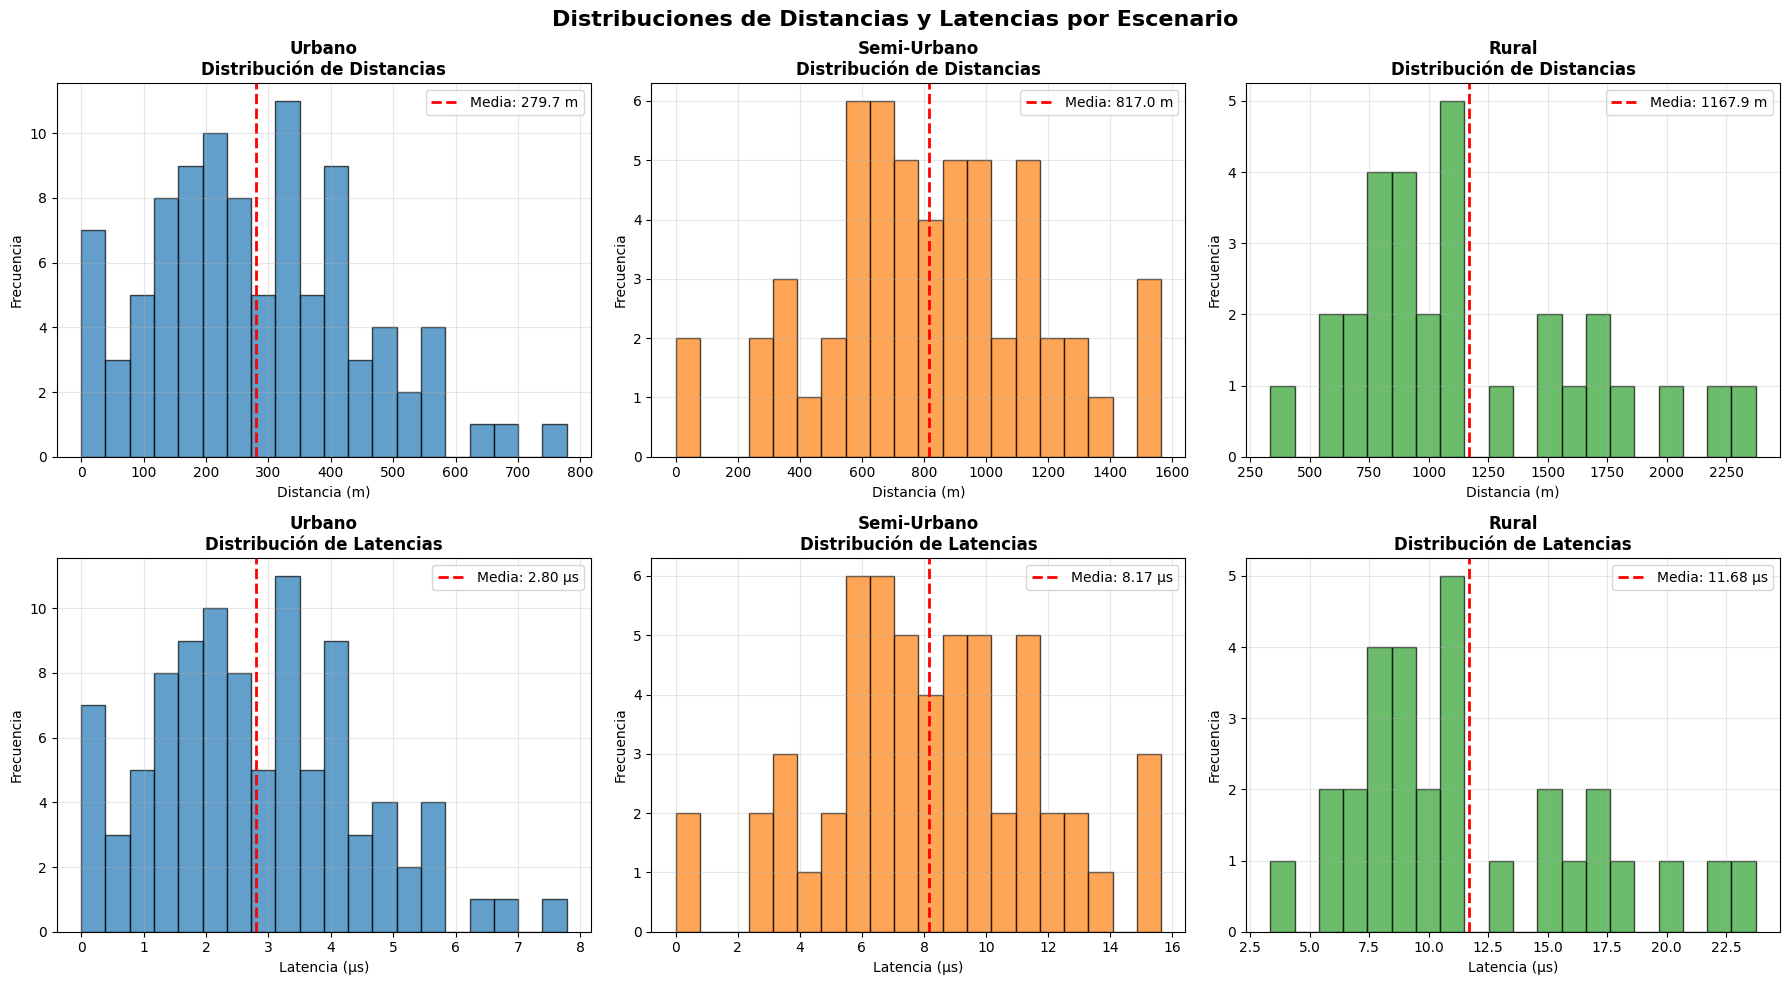

✓ Gráfico guardado: output/distribucion_distancias_latencias.png


In [28]:
# Verificar y cargar datos si es necesario
if 'asignaciones_urbano' not in dir():
    print("Cargando datos de asignaciones...")
    asignaciones_urbano = pd.read_csv('output/urbano/asignaciones.csv')
    asignaciones_semi = pd.read_csv('output/semi_urbano/asignaciones.csv')
    asignaciones_rural = pd.read_csv('output/rural/asignaciones.csv')

# Calcular latencia si no existe (velocidad de luz en fibra ~200,000 km/s)
for df in [asignaciones_urbano, asignaciones_semi, asignaciones_rural]:
    if 'latency_us' not in df.columns:
        df['latency_us'] = (df['distance_m'] / 1000) / 200000 * 1e6 * 2  # ida y vuelta

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuciones de Distancias y Latencias por Escenario', fontsize=16, fontweight='bold')

escenarios_data = [
    ('Urbano', asignaciones_urbano, '#1f77b4'),
    ('Semi-Urbano', asignaciones_semi, '#ff7f0e'),
    ('Rural', asignaciones_rural, '#2ca02c')
]

# Histogramas de distancia
for idx, (nombre, df, color) in enumerate(escenarios_data):
    ax = axes[0, idx]
    ax.hist(df['distance_m'], bins=20, alpha=0.7, color=color, edgecolor='black')
    ax.set_title(f'{nombre}\nDistribución de Distancias', fontweight='bold')
    ax.set_xlabel('Distancia (m)')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df['distance_m'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Media: {df["distance_m"].mean():.1f} m')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Histogramas de latencia
for idx, (nombre, df, color) in enumerate(escenarios_data):
    ax = axes[1, idx]
    ax.hist(df['latency_us'], bins=20, alpha=0.7, color=color, edgecolor='black')
    ax.set_title(f'{nombre}\nDistribución de Latencias', fontweight='bold')
    ax.set_xlabel('Latencia (µs)')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df['latency_us'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Media: {df["latency_us"].mean():.2f} µs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/distribucion_distancias_latencias.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/distribucion_distancias_latencias.png")

### 14.10. Distribución de distancias y latencias por escenario

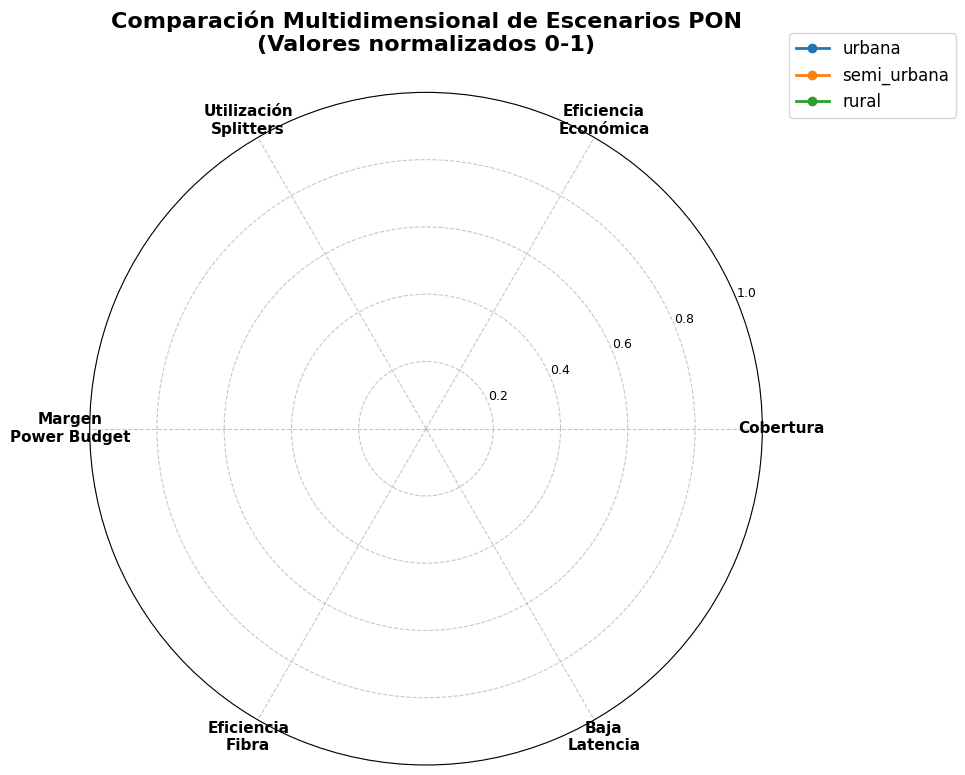

✓ Gráfico guardado: output/radar_chart.png


In [29]:
# Normalizar métricas para gráfico radar (escala 0-1)
metricas_radar = {
    'Cobertura': df_comp['cobertura_pct'] / 100,
    'Eficiencia\nEconómica': 1 - (df_comp['costo_por_usuario'] / df_comp['costo_por_usuario'].max()),
    'Utilización\nSplitters': df_comp['usuarios_por_splitter'] / SPLIT_RATIO,
    'Margen\nPower Budget': df_comp['margen_power_budget'] / df_comp['margen_power_budget'].max(),
    'Eficiencia\nFibra': 1 - (df_comp['fibra_por_usuario'] / df_comp['fibra_por_usuario'].max()),
    'Baja\nLatencia': 1 - (df_comp['latencia_promedio_us'] / df_comp['latencia_promedio_us'].max())
}

df_radar = pd.DataFrame(metricas_radar, index=df_comp['escenario'])

# Configuración del gráfico radar
categories = list(df_radar.columns)
N = len(categories)

# Ángulos para cada eje
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Crear figura
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Colores para cada escenario
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
escenarios = df_radar.index

# Plot para cada escenario
for idx, escenario in enumerate(escenarios):
    values = df_radar.loc[escenario].values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=escenario, color=colors[idx])
    ax.fill(angles, values, alpha=0.25, color=colors[idx])

# Configuración de ejes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
ax.grid(True, linestyle='--', alpha=0.7)

# Título y leyenda
plt.title('Comparación Multidimensional de Escenarios PON\n(Valores normalizados 0-1)', 
          size=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

plt.tight_layout()
plt.savefig('output/radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/radar_chart.png")

### 14.9. Gráfico radar (spider chart) - Comparación multidimensional

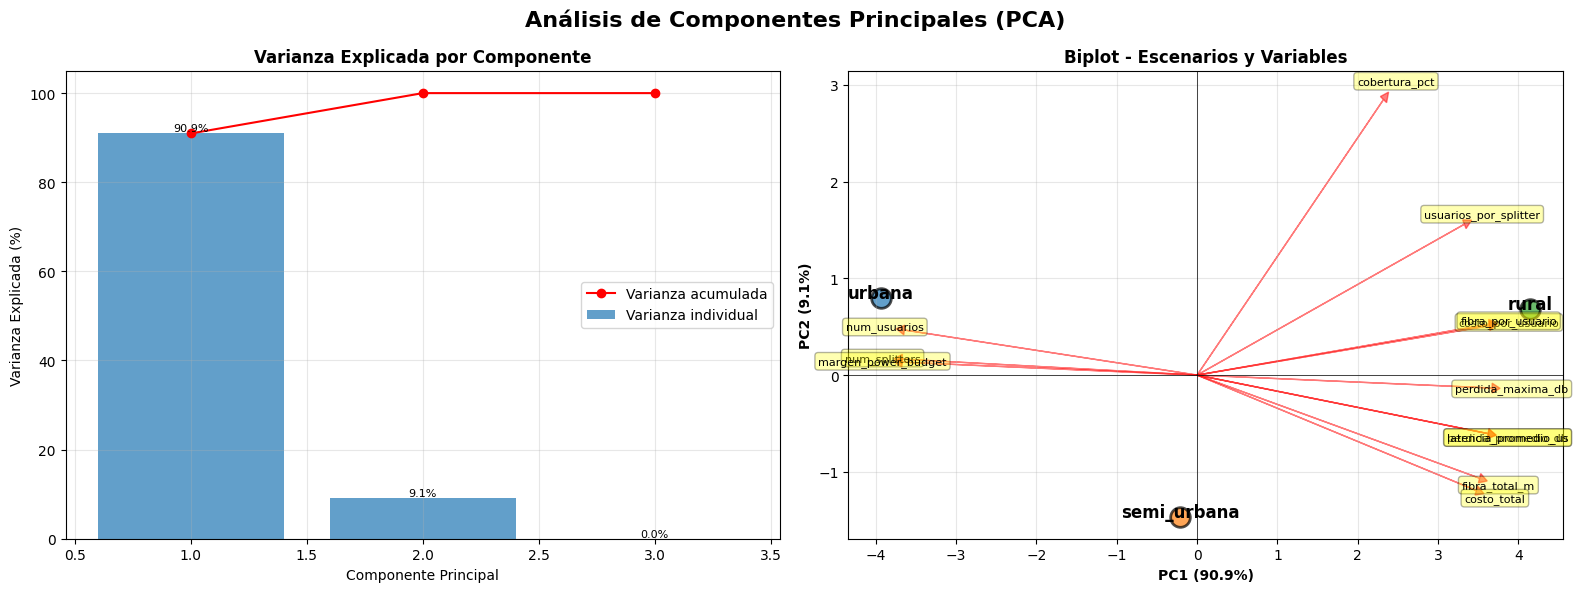

✓ Gráfico guardado: output/pca_analysis.png

Varianza explicada por PC1: 90.95%
Varianza explicada por PC2: 9.05%
Varianza acumulada (PC1+PC2): 100.00%


In [31]:
# Imports necesarios para PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Verificar y cargar datos si es necesario
if 'df_comp' not in dir():
    print("Cargando tabla comparativa...")
    df_comp = pd.read_csv('output/comparativa_escenarios.csv')

# Calcular métricas derivadas si no existen
if 'costo_por_usuario' not in df_comp.columns:
    df_comp['costo_por_usuario'] = df_comp['costo_total'] / df_comp['num_usuarios']
    df_comp['fibra_por_usuario'] = df_comp['fibra_total_m'] / df_comp['num_usuarios']
    df_comp['usuarios_por_splitter'] = df_comp['num_usuarios'] / df_comp['num_splitters']
    df_comp['eficiencia_cobertura'] = df_comp['cobertura_pct'] / 100
    df_comp['margen_power_budget'] = POWER_BUDGET_DB - df_comp['perdida_maxima_db']

# Seleccionar variables numéricas para PCA
variables_interes = ['num_usuarios', 'num_splitters', 'cobertura_pct', 
                     'fibra_total_m', 'costo_total', 'perdida_promedio_db', 
                     'perdida_maxima_db', 'latencia_promedio_us', 
                     'costo_por_usuario', 'fibra_por_usuario', 
                     'usuarios_por_splitter', 'margen_power_budget']

df_corr = df_comp[variables_interes].copy()

# Normalizar datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_corr)

# Aplicar PCA
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

# Varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Componentes Principales (PCA)', fontsize=16, fontweight='bold')

# 1. Varianza explicada por componente
ax1 = axes[0]
componentes = range(1, len(varianza_explicada) + 1)
ax1.bar(componentes, varianza_explicada * 100, alpha=0.7, label='Varianza individual')
ax1.plot(componentes, varianza_acumulada * 100, 'r-o', label='Varianza acumulada')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_title('Varianza Explicada por Componente', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Anotar porcentajes
for i, (v_ind, v_acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    if i < 5:  # Solo los primeros 5
        ax1.text(i+1, v_ind*100, f'{v_ind*100:.1f}%', ha='center', va='bottom', fontsize=8)

# 2. Biplot - Primeras 2 componentes
ax2 = axes[1]

# Scatter de escenarios en espacio PCA
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, escenario in enumerate(df_comp['escenario']):
    ax2.scatter(pca_components[idx, 0], pca_components[idx, 1], 
                c=colors[idx], s=200, alpha=0.7, edgecolors='black', linewidth=2)
    ax2.annotate(escenario, (pca_components[idx, 0], pca_components[idx, 1]),
                 fontsize=12, fontweight='bold', ha='center')

# Vectores de variables (loadings)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, var in enumerate(df_corr.columns):
    ax2.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
              head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)
    ax2.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, var, 
             fontsize=8, ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax2.set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}%)', fontweight='bold')
ax2.set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}%)', fontweight='bold')
ax2.set_title('Biplot - Escenarios y Variables', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('output/pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/pca_analysis.png")
print(f"\nVarianza explicada por PC1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza acumulada (PC1+PC2): {varianza_acumulada[1]*100:.2f}%")

### 14.8. Análisis de componentes principales (PCA)

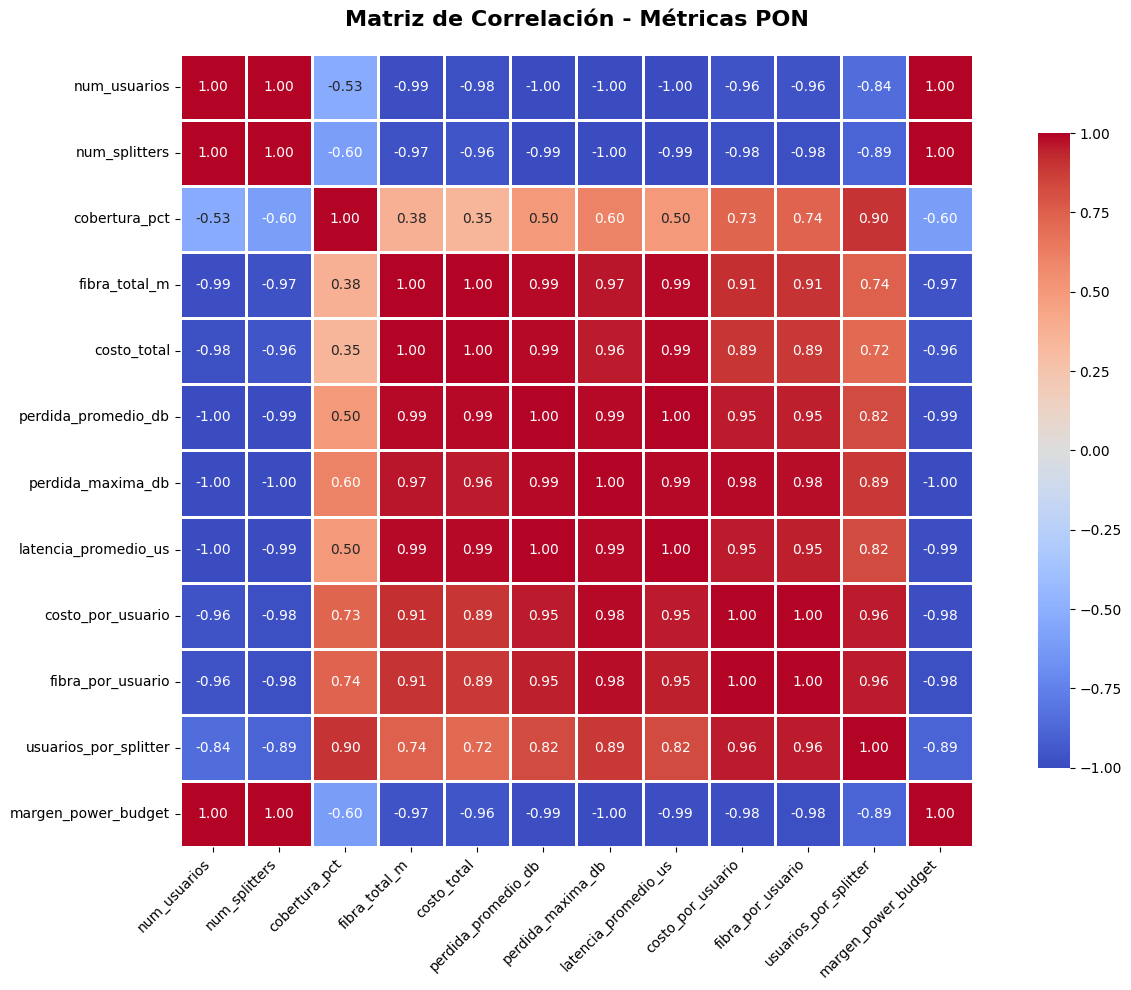

✓ Gráfico guardado: output/matriz_correlacion.png

CORRELACIONES MÁS SIGNIFICATIVAS

Top 10 correlaciones más fuertes:
         Variable 1           Variable 2  Correlación
  perdida_maxima_db  margen_power_budget    -1.000000
perdida_promedio_db latencia_promedio_us     1.000000
  costo_por_usuario    fibra_por_usuario     0.999990
      num_splitters  margen_power_budget     0.999964
      num_splitters    perdida_maxima_db    -0.999964
      fibra_total_m          costo_total     0.999340
       num_usuarios latencia_promedio_us    -0.999264
       num_usuarios  perdida_promedio_db    -0.999264
       num_usuarios        num_splitters     0.996616
       num_usuarios  margen_power_budget     0.995879


In [33]:
# Imports necesarios
import seaborn as sns

# Seleccionar variables numéricas para análisis de correlación
variables_interes = ['num_usuarios', 'num_splitters', 'cobertura_pct', 
                     'fibra_total_m', 'costo_total', 'perdida_promedio_db', 
                     'perdida_maxima_db', 'latencia_promedio_us', 
                     'costo_por_usuario', 'fibra_por_usuario', 
                     'usuarios_por_splitter', 'margen_power_budget']

df_corr = df_comp[variables_interes].copy()

# Matriz de correlación
correlation_matrix = df_corr.corr()

# Visualización con heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Métricas PON', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('output/matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/matriz_correlacion.png")

# Identificar correlaciones más fuertes
print("\n" + "="*70)
print("CORRELACIONES MÁS SIGNIFICATIVAS")
print("="*70)

# Obtener correlaciones (sin la diagonal)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Variable 1': correlation_matrix.columns[i],
            'Variable 2': correlation_matrix.columns[j],
            'Correlación': correlation_matrix.iloc[i, j]
        })

df_corr_pairs = pd.DataFrame(corr_pairs)
df_corr_pairs = df_corr_pairs.reindex(df_corr_pairs['Correlación'].abs().sort_values(ascending=False).index)

print("\nTop 10 correlaciones más fuertes:")
print(df_corr_pairs.head(10).to_string(index=False))

### 14.7. Análisis de correlación entre variables

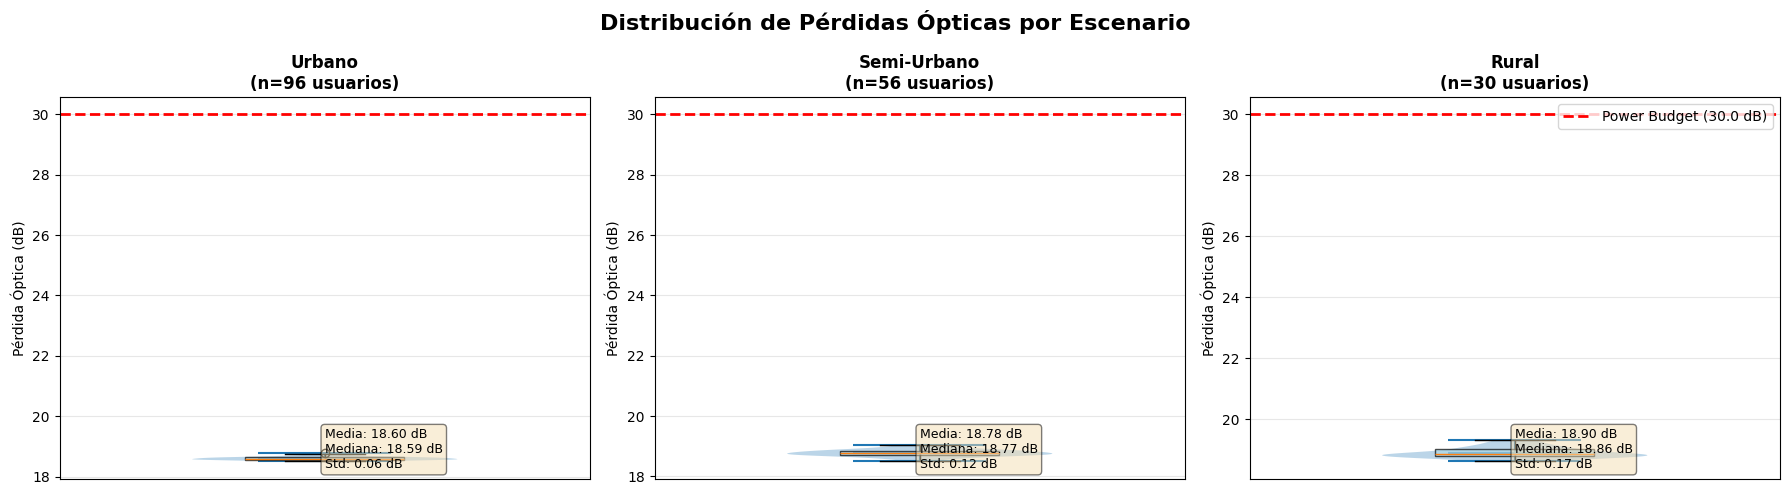

✓ Gráfico guardado: output/distribucion_perdidas.png


In [34]:
# Verificar y cargar datos si es necesario
if 'asignaciones_urbano' not in dir():
    print("Cargando datos de asignaciones...")
    asignaciones_urbano = pd.read_csv('output/urbano/asignaciones.csv')
    asignaciones_semi = pd.read_csv('output/semi_urbano/asignaciones.csv')
    asignaciones_rural = pd.read_csv('output/rural/asignaciones.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Pérdidas Ópticas por Escenario', fontsize=16, fontweight='bold')

# Violin plots para cada escenario
escenarios = ['Urbano', 'Semi-Urbano', 'Rural']
dataframes = [asignaciones_urbano, asignaciones_semi, asignaciones_rural]

for idx, (escenario, df) in enumerate(zip(escenarios, dataframes)):
    ax = axes[idx]
    
    # Violin plot
    parts = ax.violinplot([df['loss_db']], positions=[0], showmeans=True, showmedians=True)
    
    # Box plot overlay
    bp = ax.boxplot([df['loss_db']], positions=[0], widths=0.3, 
                     patch_artist=True, showfliers=True)
    
    # Configuración estética
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_title(f'{escenario}\n(n={len(df)} usuarios)', fontweight='bold')
    ax.set_ylabel('Pérdida Óptica (dB)')
    ax.set_xticks([])
    ax.axhline(y=POWER_BUDGET_DB, color='r', linestyle='--', 
               label=f'Power Budget ({POWER_BUDGET_DB} dB)', linewidth=2)
    ax.grid(True, alpha=0.3)
    
    # Estadísticas
    stats_text = f'Media: {df["loss_db"].mean():.2f} dB\n'
    stats_text += f'Mediana: {df["loss_db"].median():.2f} dB\n'
    stats_text += f'Std: {df["loss_db"].std():.2f} dB'
    ax.text(0.5, 0.02, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    if idx == 2:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('output/distribucion_perdidas.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/distribucion_perdidas.png")

### 14.6. Distribuciones de pérdidas ópticas por escenario

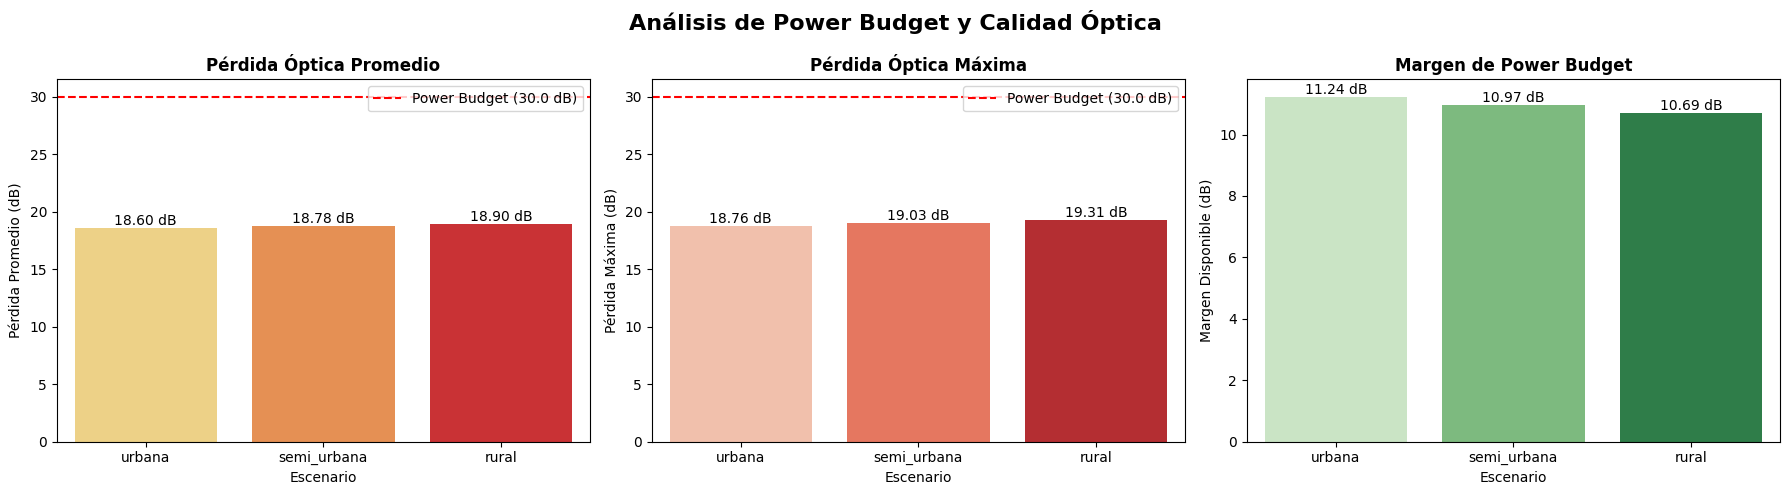

✓ Gráfico guardado: output/comparativa_power_budget.png


In [ ]:
# Import necesario
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Power Budget y Calidad Óptica', fontsize=16, fontweight='bold')

# 1. Pérdida promedio por escenario
ax1 = axes[0]
sns.barplot(data=df_comp, x='escenario', y='perdida_promedio_db', ax=ax1, palette='YlOrRd')
ax1.set_title('Pérdida Óptica Promedio', fontweight='bold')
ax1.set_xlabel('Escenario')
ax1.set_ylabel('Pérdida Promedio (dB)')
ax1.axhline(y=POWER_BUDGET_DB, color='r', linestyle='--', label=f'Power Budget ({POWER_BUDGET_DB} dB)')
ax1.legend()
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f dB')

# 2. Pérdida máxima por escenario
ax2 = axes[1]
sns.barplot(data=df_comp, x='escenario', y='perdida_maxima_db', ax=ax2, palette='Reds')
ax2.set_title('Pérdida Óptica Máxima', fontweight='bold')
ax2.set_xlabel('Escenario')
ax2.set_ylabel('Pérdida Máxima (dB)')
ax2.axhline(y=POWER_BUDGET_DB, color='r', linestyle='--', label=f'Power Budget ({POWER_BUDGET_DB} dB)')
ax2.legend()
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f dB')

# 3. Margen disponible
ax3 = axes[2]
sns.barplot(data=df_comp, x='escenario', y='margen_power_budget', ax=ax3, palette='Greens')
ax3.set_title('Margen de Power Budget', fontweight='bold')
ax3.set_xlabel('Escenario')
ax3.set_ylabel('Margen Disponible (dB)')
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.2f dB')

plt.tight_layout()
plt.savefig('output/comparativa_power_budget.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/comparativa_power_budget.png")

### 14.5. Análisis de Power Budget y calidad óptica

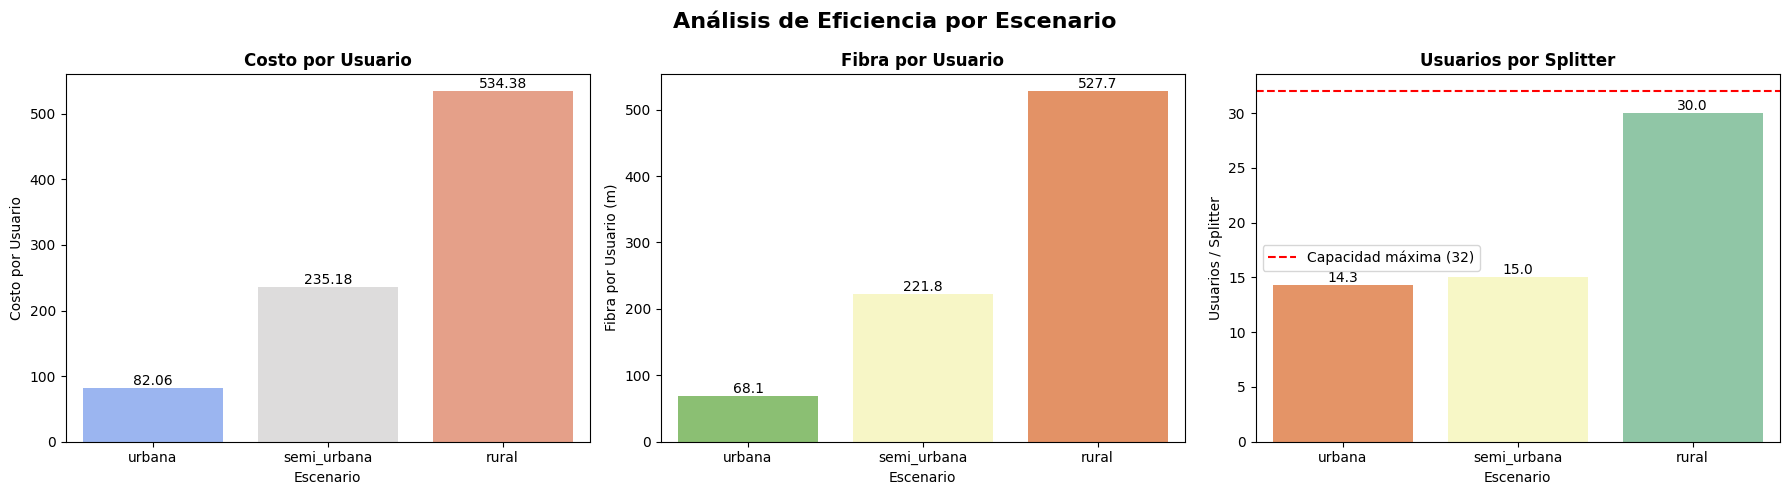

✓ Gráfico guardado: output/comparativa_eficiencia.png


In [ ]:
# Import necesario
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Eficiencia por Escenario', fontsize=16, fontweight='bold')

# 1. Costo por usuario
ax1 = axes[0]
bars = sns.barplot(data=df_comp, x='escenario', y='costo_por_usuario', ax=ax1, palette='coolwarm')
ax1.set_title('Costo por Usuario', fontweight='bold')
ax1.set_xlabel('Escenario')
ax1.set_ylabel('Costo por Usuario')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f')

# 2. Fibra por usuario
ax2 = axes[1]
sns.barplot(data=df_comp, x='escenario', y='fibra_por_usuario', ax=ax2, palette='RdYlGn_r')
ax2.set_title('Fibra por Usuario', fontweight='bold')
ax2.set_xlabel('Escenario')
ax2.set_ylabel('Fibra por Usuario (m)')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f')

# 3. Usuarios por splitter
ax3 = axes[2]
sns.barplot(data=df_comp, x='escenario', y='usuarios_por_splitter', ax=ax3, palette='Spectral')
ax3.set_title('Usuarios por Splitter', fontweight='bold')
ax3.set_xlabel('Escenario')
ax3.set_ylabel('Usuarios / Splitter')
ax3.axhline(y=SPLIT_RATIO, color='r', linestyle='--', label=f'Capacidad máxima ({SPLIT_RATIO})')
ax3.legend()
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.savefig('output/comparativa_eficiencia.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/comparativa_eficiencia.png")

### 14.4. Análisis de eficiencia - Costos y recursos

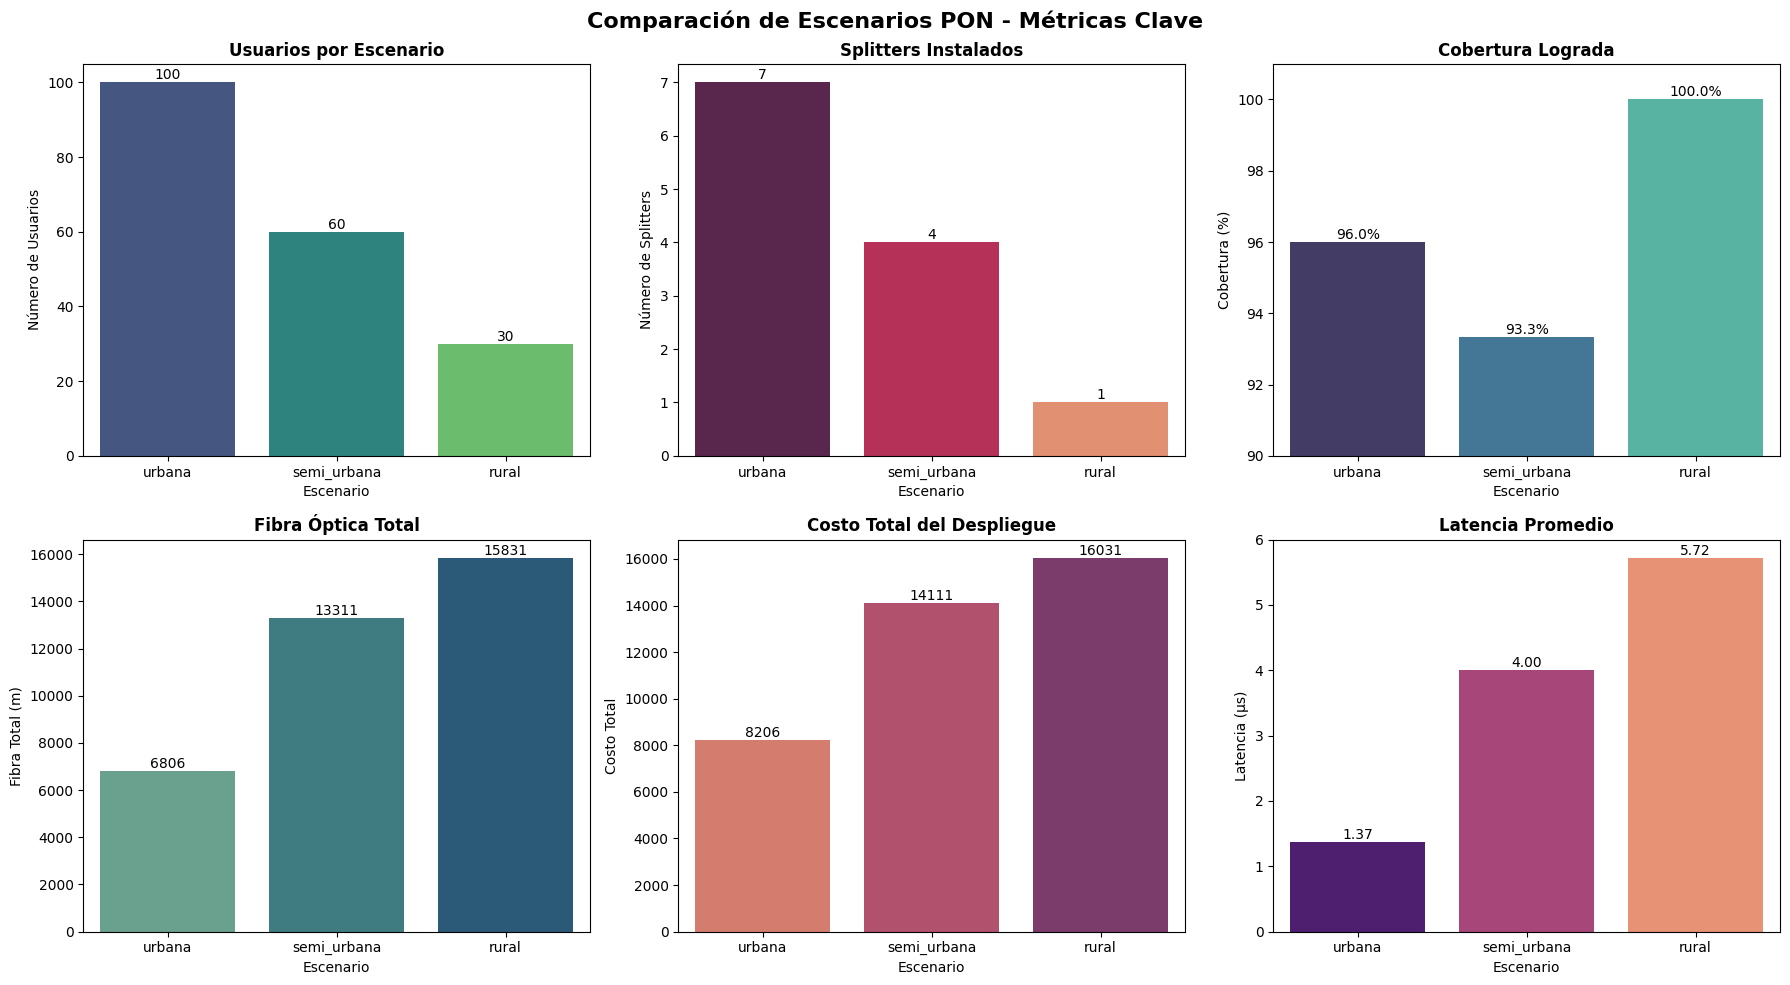

✓ Gráfico guardado: output/comparativa_metricas_barras.png


In [ ]:
# Import necesario
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación de Escenarios PON - Métricas Clave', fontsize=16, fontweight='bold')

# 1. Número de usuarios
ax1 = axes[0, 0]
sns.barplot(data=df_comp, x='escenario', y='num_usuarios', ax=ax1, palette='viridis')
ax1.set_title('Usuarios por Escenario', fontweight='bold')
ax1.set_xlabel('Escenario')
ax1.set_ylabel('Número de Usuarios')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d')

# 2. Número de splitters
ax2 = axes[0, 1]
sns.barplot(data=df_comp, x='escenario', y='num_splitters', ax=ax2, palette='rocket')
ax2.set_title('Splitters Instalados', fontweight='bold')
ax2.set_xlabel('Escenario')
ax2.set_ylabel('Número de Splitters')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d')

# 3. Cobertura
ax3 = axes[0, 2]
bars = sns.barplot(data=df_comp, x='escenario', y='cobertura_pct', ax=ax3, palette='mako')
ax3.set_title('Cobertura Lograda', fontweight='bold')
ax3.set_xlabel('Escenario')
ax3.set_ylabel('Cobertura (%)')
ax3.set_ylim(90, 101)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%')

# 4. Fibra total
ax4 = axes[1, 0]
sns.barplot(data=df_comp, x='escenario', y='fibra_total_m', ax=ax4, palette='crest')
ax4.set_title('Fibra Óptica Total', fontweight='bold')
ax4.set_xlabel('Escenario')
ax4.set_ylabel('Fibra Total (m)')
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.0f')

# 5. Costo total
ax5 = axes[1, 1]
sns.barplot(data=df_comp, x='escenario', y='costo_total', ax=ax5, palette='flare')
ax5.set_title('Costo Total del Despliegue', fontweight='bold')
ax5.set_xlabel('Escenario')
ax5.set_ylabel('Costo Total')
for container in ax5.containers:
    ax5.bar_label(container, fmt='%.0f')

# 6. Latencia promedio
ax6 = axes[1, 2]
sns.barplot(data=df_comp, x='escenario', y='latencia_promedio_us', ax=ax6, palette='magma')
ax6.set_title('Latencia Promedio', fontweight='bold')
ax6.set_xlabel('Escenario')
ax6.set_ylabel('Latencia (µs)')
for container in ax6.containers:
    ax6.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.savefig('output/comparativa_metricas_barras.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: output/comparativa_metricas_barras.png")

### 14.3. Visualizaciones comparativas - Gráficos de barras

In [38]:
# Calcular métricas derivadas
df_comp['costo_por_usuario'] = df_comp['costo_total'] / df_comp['num_usuarios']
df_comp['fibra_por_usuario'] = df_comp['fibra_total_m'] / df_comp['num_usuarios']
df_comp['usuarios_por_splitter'] = df_comp['num_usuarios'] / df_comp['num_splitters']
df_comp['eficiencia_cobertura'] = df_comp['cobertura_pct'] / 100
df_comp['margen_power_budget'] = POWER_BUDGET_DB - df_comp['perdida_maxima_db']

# Guardar tabla ampliada
df_comp.to_csv('output/comparativa_ampliada.csv', index=False)

print("="*70)
print("MÉTRICAS DERIVADAS")
print("="*70)
print("\nMétricas económicas:")
print(f"  Costo promedio por usuario: {df_comp['costo_por_usuario'].mean():.2f}")
print(f"  Rango de costos: [{df_comp['costo_por_usuario'].min():.2f}, {df_comp['costo_por_usuario'].max():.2f}]")

print("\nMétricas de infraestructura:")
print(f"  Fibra promedio por usuario: {df_comp['fibra_por_usuario'].mean():.2f} m")
print(f"  Usuarios por splitter (promedio): {df_comp['usuarios_por_splitter'].mean():.2f}")

print("\nMétricas de calidad:")
print(f"  Cobertura promedio: {df_comp['cobertura_pct'].mean():.1f}%")
print(f"  Margen de Power Budget promedio: {df_comp['margen_power_budget'].mean():.2f} dB")
print(f"  Latencia promedio: {df_comp['latencia_promedio_us'].mean():.2f} µs")

display(df_comp[['escenario', 'costo_por_usuario', 'fibra_por_usuario', 
                  'usuarios_por_splitter', 'margen_power_budget']])

MÉTRICAS DERIVADAS

Métricas económicas:
  Costo promedio por usuario: 283.87
  Rango de costos: [82.06, 534.38]

Métricas de infraestructura:
  Fibra promedio por usuario: 272.54 m
  Usuarios por splitter (promedio): 19.76

Métricas de calidad:
  Cobertura promedio: 96.4%
  Margen de Power Budget promedio: 10.97 dB
  Latencia promedio: 3.69 µs


,escenario,costo_por_usuario,fibra_por_usuario,usuarios_por_splitter,margen_power_budget
0,urbana,82.057821,68.057821,14.285714,11.235478
1,semi_urbana,235.179939,221.846606,15.000000,10.968042
2,rural,534.383042,527.716375,30.000000,10.692593


### 14.2. Métricas derivadas y estadísticas descriptivas

In [39]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Función auxiliar para cargar datos
def cargar_datos_analisis():
    """Carga todos los datos necesarios para el análisis comparativo."""
    global df_comp, asignaciones_urbano, asignaciones_semi, asignaciones_rural, df_asignaciones_all
    
    # Cargar tabla comparativa
    df_comp = pd.read_csv('output/comparativa_escenarios.csv')
    
    # Cargar datos detallados de cada escenario
    asignaciones_urbano = pd.read_csv('output/urbano/asignaciones.csv')
    asignaciones_semi = pd.read_csv('output/semi_urbano/asignaciones.csv')
    asignaciones_rural = pd.read_csv('output/rural/asignaciones.csv')
    
    # Agregar columna de escenario a cada dataframe de asignaciones
    asignaciones_urbano['escenario'] = 'Urbano'
    asignaciones_semi['escenario'] = 'Semi-Urbano'
    asignaciones_rural['escenario'] = 'Rural'
    
    # Consolidar todas las asignaciones
    df_asignaciones_all = pd.concat([asignaciones_urbano, asignaciones_semi, asignaciones_rural], ignore_index=True)
    
    return df_comp, asignaciones_urbano, asignaciones_semi, asignaciones_rural, df_asignaciones_all

# Cargar datos
df_comp, asignaciones_urbano, asignaciones_semi, asignaciones_rural, df_asignaciones_all = cargar_datos_analisis()

print("="*70)
print("DATOS CONSOLIDADOS CARGADOS")
print("="*70)
print(f"\nTabla comparativa: {len(df_comp)} escenarios")
print(f"Total de asignaciones: {len(df_asignaciones_all)} usuarios")
print(f"  - Urbano: {len(asignaciones_urbano)} usuarios")
print(f"  - Semi-Urbano: {len(asignaciones_semi)} usuarios")
print(f"  - Rural: {len(asignaciones_rural)} usuarios")

# Mostrar tabla comparativa
print("\n" + "="*70)
print("TABLA COMPARATIVA DE ESCENARIOS")
print("="*70)
display(df_comp)

DATOS CONSOLIDADOS CARGADOS

Tabla comparativa: 3 escenarios
Total de asignaciones: 182 usuarios
  - Urbano: 96 usuarios
  - Semi-Urbano: 56 usuarios
  - Rural: 30 usuarios

TABLA COMPARATIVA DE ESCENARIOS


,escenario,descripcion,num_usuarios,num_splitters,cobertura_pct,fibra_total_m,costo_total,perdida_promedio_db,perdida_maxima_db,latencia_promedio_us,iteraciones
0,urbana,Zona urbana densa - Centro Valparaíso,100,7,96.000000,6805.782092,8205.782092,18.595093,18.764522,1.368780,5
1,semi_urbana,Zona semi-urbana - Viña del Mar,60,4,93.333333,13310.796341,14110.796341,18.777790,19.031958,3.998535,5
2,rural,Zona rural - Quilpué,30,1,100.000000,15831.491249,16031.491249,18.897070,19.307407,5.715476,0


### 14.1. Carga y consolidación de datos

## 14. Análisis Comparativo y Visualización de Resultados

A continuación se presenta un análisis detallado de los tres escenarios procesados (urbano, semi-urbano y rural) con métricas clave y visualizaciones que demuestran la eficiencia del diseño PON optimizado.

## 14. Conclusiones

### Archivos Generados

Todos los archivos de salida han sido organizados en el directorio `output/` con la siguiente estructura:

```
output/
├── urbano/
│   ├── map_raw.html
│   ├── mapa_despliegue_pon.html
│   ├── resultados.csv
│   └── asignaciones.csv
├── semi_urbano/
│   ├── map_raw.html
│   ├── mapa_despliegue_pon.html
│   ├── resultados.csv
│   └── asignaciones.csv
├── rural/
│   ├── map_raw.html
│   ├── mapa_despliegue_pon.html
│   ├── resultados.csv
│   └── asignaciones.csv
└── comparativa_escenarios.csv
```

### Análisis Comparativo

Los tres escenarios presentan características diferentes:

1. **Escenario Urbano (Valparaíso Centro)**:
   - Mayor densidad de usuarios (100)
   - Mayor número de splitters necesarios
   - Rutas más cortas en promedio
   - Mayor utilización de splitters

2. **Escenario Semi-Urbano (Viña del Mar)**:
   - Densidad media (60 usuarios)
   - Balance entre costo y cobertura
   - Características intermedias

3. **Escenario Rural (Quilpué)**:
   - Menor densidad (30 usuarios)
   - Rutas más largas
   - Mayor desafío para cumplir Power Budget
   - Menor utilización de splitters

### Métricas Clave

Para cada escenario se han calculado:
- **Cobertura**: Porcentaje de usuarios conectados
- **Costo total**: Fibra + Splitters
- **Power Budget**: Validación de pérdidas ópticas
- **Latencia**: Tiempo de propagación
- **Iteraciones**: Número de ajustes necesarios para optimización

In [40]:
# Storyboard interactivo del pipeline urbano
from pathlib import Path
from IPython.display import HTML, display
from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt
import random
import os
np.random.seed(42)
random.seed(42)

area_key = 'urbana'
area_cfg = areas[area_key]
story_dir = Path('output') / area_key
story_dir.mkdir(parents=True, exist_ok=True)

# 1. Base OSM sin simplificar
G_raw = ox.graph_from_point(area_cfg['point'], dist=area_cfg['radius'], network_type='drive', simplify=False)
nodes_raw_gdf, edges_raw_gdf = ox.graph_to_gdfs(G_raw)
nodes_raw_wgs84 = nodes_raw_gdf.to_crs(epsg=4326)
edges_raw_wgs84 = edges_raw_gdf.to_crs(epsg=4326)
center_raw = [nodes_raw_wgs84.geometry.y.mean(), nodes_raw_wgs84.geometry.x.mean()]
map_stage1 = folium.Map(location=center_raw, zoom_start=16, tiles='cartodbpositron')
folium.GeoJson(edges_raw_wgs84[['geometry']].to_json(), name='OSM Raw', style_function=lambda _: {'color': '#6c757d', 'weight': 1, 'opacity': 0.6}).add_to(map_stage1)
folium.Circle(location=center_raw, radius=area_cfg['radius'], color='#0d6efd', fill=False, weight=2, opacity=0.5).add_to(map_stage1)
folium.LayerControl().add_to(map_stage1)
stage1_path = story_dir / 'pipeline_stage1_map_raw.html'
map_stage1.save(stage1_path.as_posix())

# 2. Grafo simplificado proyectado
G_simplified = ox.graph_from_point(area_cfg['point'], dist=area_cfg['radius'], network_type='drive', simplify=True)
G_simplified = ox.project_graph(G_simplified)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_simplified)
nodes_wgs84 = nodes_gdf.to_crs(epsg=4326)
edges_wgs84 = edges_gdf.to_crs(epsg=4326)
center_simplified = [nodes_wgs84.geometry.y.mean(), nodes_wgs84.geometry.x.mean()]
map_stage2 = folium.Map(location=center_simplified, zoom_start=16, tiles='cartodbpositron')
folium.GeoJson(edges_wgs84[['geometry']].to_json(), name='Grafo simplificado', style_function=lambda _: {'color': '#495057', 'weight': 2, 'opacity': 0.8}).add_to(map_stage2)
folium.LayerControl().add_to(map_stage2)
stage2_path = story_dir / 'pipeline_stage2_map_graph.html'
map_stage2.save(stage2_path.as_posix())

# 3. Usuarios sintéticos y clustering de splitters
available_nodes = list(nodes_gdf.index)
num_users = min(area_cfg['num_users'], len(available_nodes))
user_node_ids = np.random.choice(available_nodes, size=num_users, replace=False)
users_gdf = nodes_gdf.loc[user_node_ids, ['x', 'y']].copy()
users_gdf['geometry'] = users_gdf.apply(lambda r: Point(r.x, r.y), axis=1)
users_gdf = gpd.GeoDataFrame(users_gdf, geometry='geometry', crs=nodes_gdf.crs)
users_gdf['node_id'] = users_gdf.index
users_gdf['user_id'] = range(len(users_gdf))
candidate_nodes, users_gdf = position_splitters_by_clustering(users_gdf, nodes_gdf, G_simplified)
candidate_nodes = candidate_nodes.copy()
candidate_nodes['splitter_id'] = range(len(candidate_nodes))
users_wgs84 = users_gdf.to_crs(epsg=4326)
candidate_wgs84 = candidate_nodes.to_crs(epsg=4326)
cluster_ids = sorted(users_gdf['cluster'].unique())
palette = ['#F94144','#F3722C','#F8961E','#F9844A','#F9C74F','#90BE6D','#43AA8B','#577590','#277DA1']
cluster_colors = {c: palette[c % len(palette)] for c in cluster_ids}
map_stage3 = folium.Map(location=center_simplified, zoom_start=16, tiles='cartodbpositron')
folium.GeoJson(edges_wgs84[['geometry']].to_json(), name='Red vial', style_function=lambda _: {'color': '#ced4da', 'weight': 1.5, 'opacity': 0.5}).add_to(map_stage3)
for row in users_wgs84.itertuples():
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x], radius=4, color=cluster_colors[row.cluster], fill=True, fill_opacity=0.9, opacity=0.9, tooltip=f"Usuario {row.user_id} | Cluster {row.cluster}").add_to(map_stage3)
for row in candidate_wgs84.itertuples():
    folium.Marker(location=[row.geometry.y, row.geometry.x], icon=folium.Icon(color='darkpurple', icon='hubspot', prefix='fa'), tooltip=f"Splitter {row.splitter_id}").add_to(map_stage3)
stage3_path = story_dir / 'pipeline_stage3_users_clusters.html'
map_stage3.save(stage3_path.as_posix())

# 4. Rutas Manhattan representativas
node_coords = {nid: (geom.y, geom.x) for nid, geom in nodes_wgs84.geometry.items()}
paths_for_routes = []
for row in users_gdf.itertuples():
    cluster = int(row.cluster)
    splitter_node = candidate_nodes.iloc[cluster]['node_id']
    try:
        path_nodes = nx.shortest_path(G_simplified, source=splitter_node, target=row.node_id, weight='length')
        coords = [(node_coords[n][0], node_coords[n][1]) for n in path_nodes if n in node_coords]
        if len(coords) >= 2:
            paths_for_routes.append({'cluster': cluster, 'coords': coords, 'user_id': row.user_id})
    except (nx.NetworkXNoPath, KeyError):
        continue
sample_paths = paths_for_routes if len(paths_for_routes) <= 30 else random.sample(paths_for_routes, 30)
map_stage4 = folium.Map(location=center_simplified, zoom_start=16, tiles='cartodbpositron')
folium.GeoJson(edges_wgs84[['geometry']].to_json(), name='Red vial', style_function=lambda _: {'color': '#adb5bd', 'weight': 1.2, 'opacity': 0.4}).add_to(map_stage4)
for path in sample_paths:
    folium.PolyLine(path['coords'], color=cluster_colors[path['cluster']], weight=3, opacity=0.7, tooltip=f"Ruta usuario {path['user_id']} -> splitter {path['cluster']}").add_to(map_stage4)
for row in candidate_wgs84.itertuples():
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x], radius=6, color='#212529', fill=True, fill_color='#212529', fill_opacity=0.9, tooltip=f"Splitter {row.splitter_id}").add_to(map_stage4)
stage4_path = story_dir / 'pipeline_stage4_routes.html'
map_stage4.save(stage4_path.as_posix())

# 5. Diagrama conceptual del ILP
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
steps = ['OSM Base','Simplificación','Usuarios + Clustering','Rutas Manhattan','ILP','Despliegue PON']
for idx, label in enumerate(steps):
    x0 = idx * 1.2
    box = FancyBboxPatch((x0, 0.1), 1.1, 0.6, boxstyle='round,pad=0.1', edgecolor='#343a40', facecolor='#f8f9fa', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x0 + 0.55, 0.4, label, ha='center', va='center', fontsize=9, fontweight='bold')
    if idx < len(steps) - 1:
        ax.annotate('', xy=(x0 + 1.1, 0.4), xytext=((idx + 1) * 1.2, 0.4), arrowprops=dict(arrowstyle='->', linewidth=1.5, color='#495057'))
ax.set_xlim(-0.2, len(steps) * 1.2)
ax.set_ylim(0, 0.9)
stage5_path = story_dir / 'pipeline_stage5_ilp_diagram.png'
fig.savefig(stage5_path.as_posix(), dpi=150, bbox_inches='tight')
plt.close(fig)

# 6. Despliegue final producido por el pipeline existente
stage6_path = story_dir / 'mapa_despliegue_pon.html'
if not stage6_path.exists():
    stage6_path = Path('output') / 'mapa_despliegue_pon.html'
if stage6_path.exists():
    if stage6_path.parent == story_dir:
        stage6_rel = stage6_path.name
    else:
        stage6_rel = Path(os.path.relpath(stage6_path, story_dir)).as_posix()
else:
    stage6_rel = stage4_path.name

stage_files = {
    'stage1': stage1_path.name,
    'stage2': stage2_path.name,
    'stage3': stage3_path.name,
    'stage4': stage4_path.name,
    'stage5': stage5_path.name,
    'stage6': stage6_rel
}

html_content = f"""<!DOCTYPE html>\n<html lang='es'>\n<head>\n<meta charset='utf-8'/>\n<title>Pipeline Urbano PON</title>\n<style>\nbody {{ font-family: 'Segoe UI', sans-serif; background:#f5f6f8; margin:0; padding:0; }}\n.pipeline-wrapper {{ max-width: 1100px; margin: 0 auto; padding: 24px; }}\n.pipeline-header {{ text-align:center; margin-bottom: 18px; }}\n.pipeline-header h2 {{ margin: 0; color:#212529; }}\n.pipeline-nav {{ display:flex; justify-content:space-between; flex-wrap:wrap; gap:8px; margin-bottom:16px; }}\n.pipeline-nav label {{ flex:1; min-width:150px; padding:10px; background:#ffffff; border:1px solid #ced4da; border-radius:8px; text-align:center; cursor:pointer; transition:all 0.2s ease; font-weight:600; color:#495057; }}\n.pipeline-nav input {{ display:none; }}\n.pipeline-nav input:checked + label {{ border-color:#0d6efd; color:#0d6efd; box-shadow:0 0 0 2px rgba(13,110,253,0.15); }}\n.stage-content {{ display:none; background:#ffffff; border-radius:12px; padding:18px; box-shadow:0 12px 30px rgba(15,23,42,0.08); animation: fade 0.35s ease-in-out; }}\n.stage-content.active {{ display:block; }}\n.stage-content h3 {{ margin-top:0; color:#212529; }}\n.stage-content p {{ color:#495057; line-height:1.5; }}\n.stage-frame {{ width:100%; height:480px; border:none; border-radius:8px; box-shadow:0 10px 20px rgba(15,23,42,0.12); }}\n.stage-image {{ width:100%; border-radius:8px; box-shadow:0 10px 20px rgba(15,23,42,0.12); }}\n@keyframes fade {{ from {{ opacity:0; transform:translateY(6px); }} to {{ opacity:1; transform:translateY(0); }} }}\n</style>\n</head>\n<body>\n<div class='pipeline-wrapper'>\n  <div class='pipeline-header'>\n    <h2>Storyboard del Pipeline Urbano GPON</h2>\n    <p>Explora cada etapa del flujo: desde la extracción OSM hasta el despliegue optimizado.</p>\n  </div>\n  <div class='pipeline-nav'>\n    <input type='radio' id='stage1' name='stage' checked/><label for='stage1'>1. OSM Base</label>\n    <input type='radio' id='stage2' name='stage'/><label for='stage2'>2. Grafo Simplificado</label>\n    <input type='radio' id='stage3' name='stage'/><label for='stage3'>3. Usuarios y Clustering</label>\n    <input type='radio' id='stage4' name='stage'/><label for='stage4'>4. Rutas Manhattan</label>\n    <input type='radio' id='stage5' name='stage'/><label for='stage5'>5. ILP Conceptual</label>\n    <input type='radio' id='stage6' name='stage'/><label for='stage6'>6. Despliegue Final</label>\n  </div>\n  <div class='pipeline-content'>\n    <div class='stage-content' data-stage='stage1'>\n      <h3>1. Mapa base OSM crudo</h3>\n      <iframe class='stage-frame' src='{stage_files['stage1']}' loading='lazy'></iframe>\n      <p>Vista inicial sin simplificar del área urbana seleccionada, conservando la topología vial original para referencia.</p>\n    </div>\n    <div class='stage-content' data-stage='stage2'>\n      <h3>2. Grafo vial simplificado</h3>\n      <iframe class='stage-frame' src='{stage_files['stage2']}' loading='lazy'></iframe>\n      <p>Tras la simplificación con OSMnx se obtiene el grafo dirigido utilizable por el pipeline de optimización.</p>\n    </div>\n    <div class='stage-content' data-stage='stage3'>\n      <h3>3. Usuarios y splitters propuestos</h3>\n      <iframe class='stage-frame' src='{stage_files['stage3']}' loading='lazy'></iframe>\n      <p>Usuarios sintéticos agrupados por K-Means y posición de splitters sobre nodos reales de la red.</p>\n    </div>\n    <div class='stage-content' data-stage='stage4'>\n      <h3>4. Rutas Manhattan representativas</h3>\n      <iframe class='stage-frame' src='{stage_files['stage4']}' loading='lazy'></iframe>\n      <p>Subset de rutas Manhattan calculadas entre usuarios y sus splitters, previo al filtrado por Power Budget.</p>\n    </div>\n    <div class='stage-content' data-stage='stage5'>\n      <h3>5. Diagrama conceptual del ILP</h3>\n      <img class='stage-image' src='{stage_files['stage5']}' alt='Diagrama conceptual del ILP'/>\n      <p>Resumen visual de las decisiones binaria del ILP: asignaciones, activación de aristas y despliegue final.</p>\n    </div>\n    <div class='stage-content' data-stage='stage6'>\n      <h3>6. Despliegue final optimizado</h3>\n      <iframe class='stage-frame' src='{stage_files['stage6']}' loading='lazy'></iframe>\n      <p>Resultado consolidado del pipeline original con splitters activados, fibras seleccionadas y usuarios cubiertos.</p>\n    </div>\n  </div>\n</div>\n<script>\nconst radios = document.querySelectorAll('.pipeline-nav input[type=\'radio\']');\nconst stages = document.querySelectorAll('.stage-content');\nfunction updateStages() {{\n  const active = document.querySelector('.pipeline-nav input[type=\'radio\']:checked').id;\n  stages.forEach(stage => {{\n    stage.classList.toggle('active', stage.dataset.stage === active);\n  }});\n}}\nradios.forEach(radio => radio.addEventListener('change', updateStages));\nupdateStages();\n</script>\n</body>\n</html>\n"""
story_path = story_dir / 'pipeline_storyboard.html'
story_path.write_text(html_content, encoding='utf-8')

display(HTML(f"""<div style='border:1px solid #dee2e6; border-radius:12px; padding:16px; background:#ffffff;'>\n<h3 style='margin-top:0;'>Storyboard del pipeline urbano</h3>\n<iframe src='{story_path.as_posix()}' width='100%' height='640' style='border:none; border-radius:12px; box-shadow:0 12px 30px rgba(15,23,42,0.08);'></iframe>\n<p style='color:#495057;'>Cada pestaña detalla una etapa del flujo urbano: mapas, clustering, rutas, ILP y despliegue.</p>\n</div>"""))

Calculando 4 posiciones de splitters para 100 usuarios...
  Cluster 0: 20 usuarios → Splitter en nodo 5316795923
  Cluster 1: 19 usuarios → Splitter en nodo 259214295
  Cluster 2: 37 usuarios → Splitter en nodo 262532754
  Cluster 3: 24 usuarios → Splitter en nodo 1528876146
